# cDVGAN Evaluation Notebook

Compare the **TensorFlow cDVGAN (epoch 210)** and **PyTorch cDVGAN** generators using:

1. Waveform visualisation — real vs TF vs PyTorch
2. UMAP dimensionality reduction
3. Gravity Spy classification (requires `gengli` / `gravityspy`)

**Before running:**
- Set `TF_GENERATOR_PATH` to your local `.keras` file.
- Copy PyTorch checkpoints from CIT into `weights/pytorch/` (see the README there).
- Set `PYTORCH_EPOCH` to the epoch you want to evaluate.

## Configuration

In [1]:
import os
import sys
from pathlib import Path

# ── Path configuration ────────────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve()          # run from project root
DATA_DIR     = PROJECT_ROOT / "data"        # .npy files (gitignored, see scripts/setup_local.sh)
PLOTS_DIR    = PROJECT_ROOT / "evaluation_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# TF generator (Keras 3 format — converted from Keras 2 via scripts/convert_keras2_to_keras3.py)
TF_GENERATOR_PATH = PROJECT_ROOT / "weights" / "tensorflow" / "generator_210_keras3.keras"

# PyTorch generator: set to None to skip PyTorch evaluation
PYTORCH_WEIGHTS_DIR = PROJECT_ROOT / "weights" / "pytorch"
PYTORCH_EPOCH = 225          # e.g. 25, 50, ..., 500

# Generation parameters
NOISE_DIM        = 100
NUM_CLASSES      = 7
SAMPLES_PER_CLASS = 100     # samples to generate per class for UMAP / GravitySpy
LABEL_ORDER = [
    "Blip", "Fast_Scattering", "Koi_Fish",
    "Low_Frequency_Burst", "Scattered_Light", "Tomte", "Whistle"
]

print("Project root :", PROJECT_ROOT)
print("TF weights   :", TF_GENERATOR_PATH)
print("PT weights   :", PYTORCH_WEIGHTS_DIR / f"generator_{PYTORCH_EPOCH}.pt")

Project root : /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor
TF weights   : /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/weights/tensorflow/generator_210_keras3.keras
PT weights   : /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/weights/pytorch/generator_225.pt


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap.umap_ as umap

# try:
#     import scienceplots
#     plt.style.use(["science", "no-latex"])
# except ImportError:
#     pass  # scienceplots optional

# matplotlib.rcParams.update({"text.usetex": False})

## 1. Load Real Data

In [3]:
X_real = np.load(DATA_DIR / "glitch_GAN_samples_scaled_balanced.npy")
y_onehot = np.load(DATA_DIR / "glitch_GAN_labels_balanced.npy")
label_order_npy = np.load(DATA_DIR / "glitch_GAN_label_order.npy")

# Use the canonical order from configuration
y_real = np.array(LABEL_ORDER)[np.argmax(y_onehot, axis=1)]

print(f"Real signals : {X_real.shape}")
print(f"Labels       : {y_onehot.shape}")
print(f"Classes      : {LABEL_ORDER}")

Real signals : (35000, 8192)
Labels       : (35000, 7)
Classes      : ['Blip', 'Fast_Scattering', 'Koi_Fish', 'Low_Frequency_Burst', 'Scattered_Light', 'Tomte', 'Whistle']


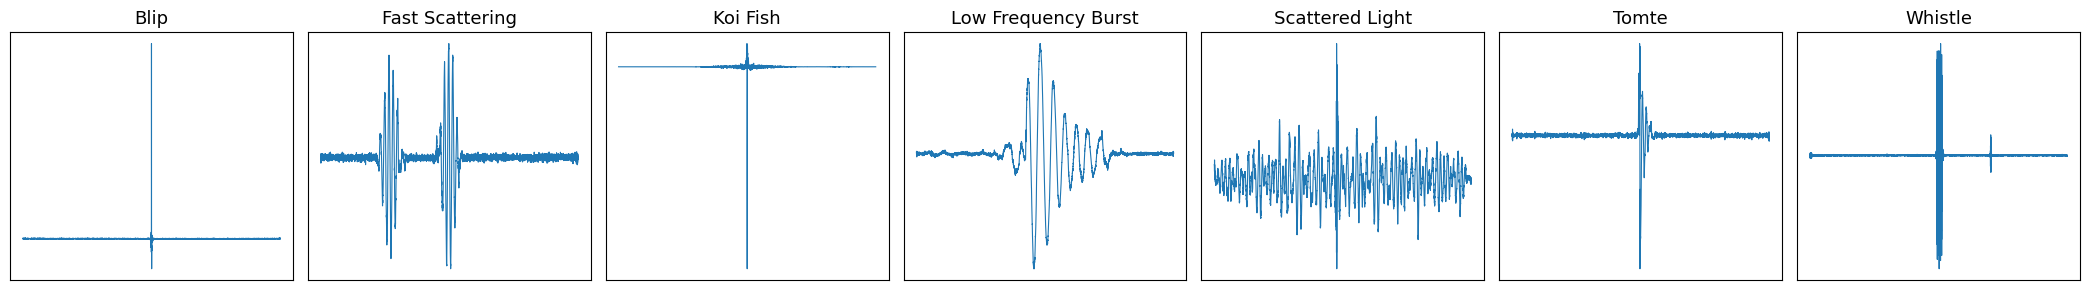

In [4]:
# ── Plot one example per class ────────────────────────────────────────────────
def plot_per_class_row(X, y, label_order, color, save_name=None):
    fig, axes = plt.subplots(1, len(label_order), figsize=(3 * len(label_order), 3))
    for i, lbl in enumerate(label_order):
        idx = np.where(y == lbl)[0]
        signal = X[np.random.choice(idx)]
        axes[i].plot(signal, lw=0.8, color=color)
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].set_title(lbl.replace("_", " "), fontsize=13)
    plt.tight_layout()
    if save_name:
        plt.savefig(PLOTS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    plt.show()

plot_per_class_row(X_real, y_real, LABEL_ORDER, color="C0", save_name="real_waveforms_row")

## 2. TensorFlow Generator (epoch 210)

Loads `generator_210.keras` — the TF cDVGAN checkpoint that produced good results
at epoch 210 during the original training run.

In [5]:
import keras

try:
    tf_generator = keras.models.load_model(str(TF_GENERATOR_PATH), compile=False)
    print(f"Loaded TF generator from: {TF_GENERATOR_PATH}")
    tf_generator.summary(line_length=80)
    TF_AVAILABLE = True
except Exception as e:
    print(f"[WARNING] Could not load TF generator: {e}")
    TF_AVAILABLE = False

Loaded TF generator from: /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/weights/tensorflow/generator_210_keras3.keras


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1         │ (None, 7)         │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ input_layer           │ (None, 100)       │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense (Dense)         │ (None, 32)        │         224 │ input_layer_1[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate           │ (None, 132)       │           0 │ input_layer[0][0], │
│ (Concatenate)         │                   │             │ dense[0][0]        │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_1 (Dense)       │ (None, 4096)      │     540,672 │ concatenate[0][0]  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu (ReLU)          │ (None, 4096)      │           0 │ dense_1[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ reshape (Reshape)     │ (None, 256, 16)   │           0 │ re_lu[0][0]        │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ up_sampling1d         │ (None, 512, 16)   │           0 │ reshape[0][0]      │
│ (UpSampling1D)        │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv1d (Conv1D)       │ (None, 512, 512)  │     147,456 │ up_sampling1d[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, 512, 512)  │       2,048 │ conv1d[0][0]       │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_1 (ReLU)        │ (None, 512, 512)  │           0 │ batch_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ up_sampling1d_1       │ (None, 1024, 512) │           0 │ re_lu_1[0][0]      │
│ (UpSampling1D)        │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv1d_1 (Conv1D)     │ (None, 1024, 256) │   2,359,296 │ up_sampling1d_1[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, 1024, 256) │       1,024 │ conv1d_1[0][0]     │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_2 (ReLU)        │ (None, 1024, 256) │           0 │ batch_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ up_sampling1d_2       │ (None, 2048, 256) │           0 │ re_lu_2[0][0]      │
│ (UpSampling1D)        │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv1d_2 (Conv1D)     │ (None, 2048, 128) │     589,824 │ up_sampling1d_2[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, 2048, 128) │         512 │ conv1d_2[0][0]     │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_3 (ReLU)        │ (None, 2048, 128) │           0 │ batch_normalizati… │
├───────────────────────┼──────

 Total params: 3,789,920 (14.46 MB)

 Trainable params: 3,788,000 (14.45 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [6]:
if TF_AVAILABLE:
    import tensorflow as tf

    num_examples = NUM_CLASSES * SAMPLES_PER_CLASS
    noise_all       = np.random.randn(num_examples, NOISE_DIM).astype("float32")
    class_all       = np.repeat(np.eye(NUM_CLASSES, dtype="float32"), SAMPLES_PER_CLASS, axis=0)

    # Call the model directly in one shot (no per-step Python overhead from predict())
    @tf.function
    def generate_batch(noise, labels):
        return tf_generator([noise, labels], training=False)

    CHUNK = 2048
    chunks = []
    for i in range(0, num_examples, CHUNK):
        chunks.append(generate_batch(noise_all[i:i+CHUNK], class_all[i:i+CHUNK]).numpy())
    X_fake_tf = np.concatenate(chunks, axis=0)
    y_fake_tf = np.repeat(LABEL_ORDER, SAMPLES_PER_CLASS)

    print(f"TF generated  : {X_fake_tf.shape}  ({SAMPLES_PER_CLASS} per class)")
else:
    X_fake_tf = None
    y_fake_tf  = None

TF generated  : (700, 8192)  (100 per class)


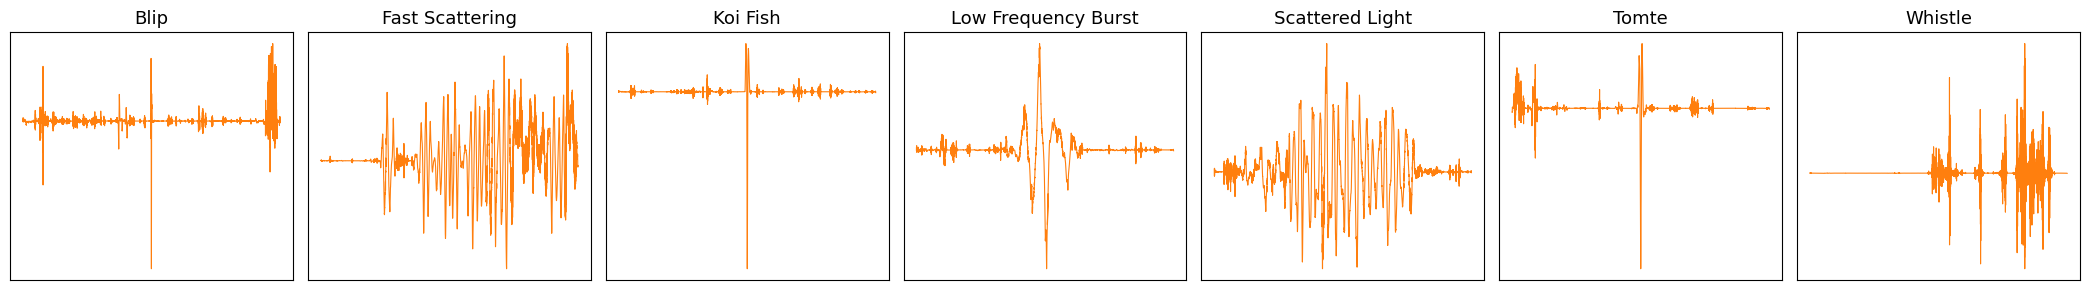

In [7]:
if TF_AVAILABLE:
    plot_per_class_row(X_fake_tf, y_fake_tf, LABEL_ORDER,
                       color="C1", save_name="tf_generated_waveforms_row")

## 3. PyTorch Generator

Loads `generator_{PYTORCH_EPOCH}.pt` from `weights/pytorch/`.
Copy checkpoint files from CIT before running this section
(see `weights/pytorch/README.md`).

In [8]:
import torch

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from cdvgan.model_components import Generator

pt_ckpt_path = PYTORCH_WEIGHTS_DIR / f"generator_{PYTORCH_EPOCH}.pt"

try:
    generator_pt = Generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES)
    state = torch.load(pt_ckpt_path, map_location="cpu")
    generator_pt.load_state_dict(state)
    generator_pt.eval()
    print(f"Loaded PyTorch generator (epoch {PYTORCH_EPOCH}) from: {pt_ckpt_path}")
    PT_AVAILABLE = True
except FileNotFoundError:
    print(f"[WARNING] Checkpoint not found: {pt_ckpt_path}")
    print("Copy generator_*.pt files from CIT into weights/pytorch/ (see README there).")
    PT_AVAILABLE = False
except Exception as e:
    print(f"[WARNING] Could not load PyTorch generator: {e}")
    PT_AVAILABLE = False

Loaded PyTorch generator (epoch 225) from: /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/weights/pytorch/generator_225.pt


In [9]:
if PT_AVAILABLE:
    num_examples = NUM_CLASSES * SAMPLES_PER_CLASS
    class_vectors_pt = np.repeat(np.eye(NUM_CLASSES), SAMPLES_PER_CLASS, axis=0)

    with torch.no_grad():
        noise_pt   = torch.randn(num_examples, NOISE_DIM)
        class_t    = torch.tensor(class_vectors_pt, dtype=torch.float32)
        X_fake_pt  = generator_pt(noise_pt, class_t).numpy()

    y_fake_pt = np.repeat(LABEL_ORDER, SAMPLES_PER_CLASS)
    print(f"PyTorch generated : {X_fake_pt.shape}  ({SAMPLES_PER_CLASS} per class)")
else:
    X_fake_pt = None
    y_fake_pt = None

PyTorch generated : (700, 8192)  (100 per class)


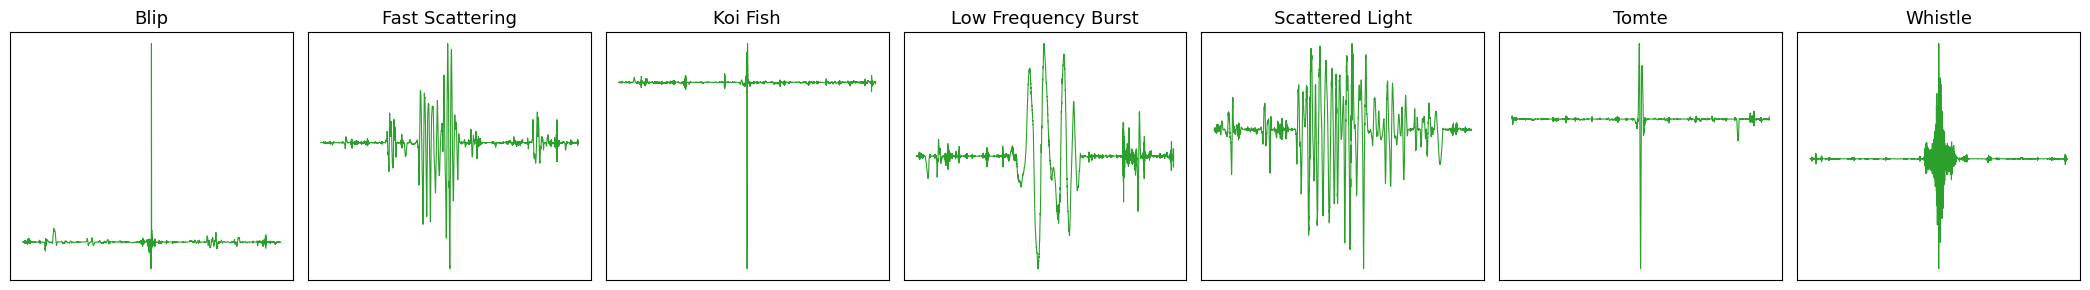

In [10]:
if PT_AVAILABLE:
    plot_per_class_row(X_fake_pt, y_fake_pt, LABEL_ORDER,
                       color="C2", save_name="pt_generated_waveforms_row")

### 3a. PyTorch — checkpoint comparison

One vertex sample per class for each downloaded checkpoint. Quick visual check of how output quality evolves across training.

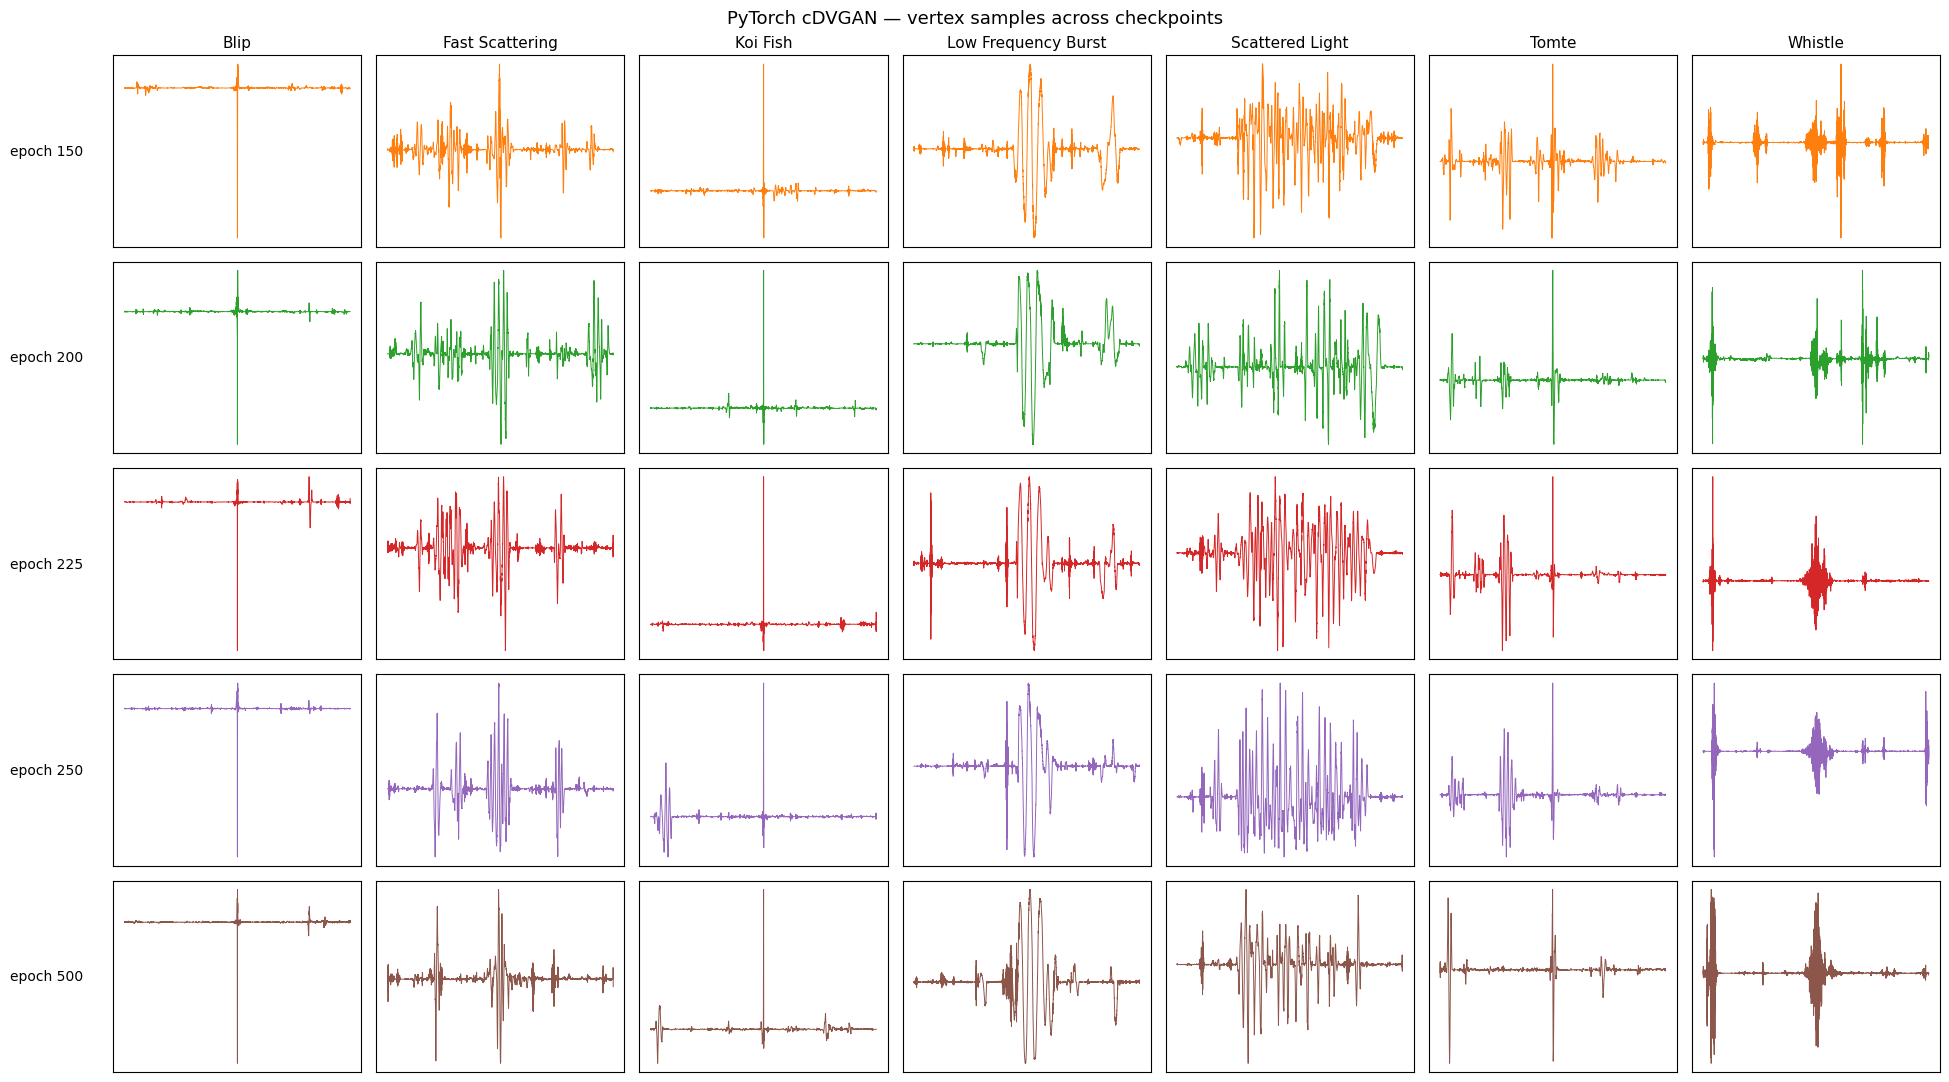

In [11]:
PT_COMPARE_EPOCHS = [150, 200, 225, 250, 500]   # adjust to whichever .pt files you have

fig, axes = plt.subplots(
    len(PT_COMPARE_EPOCHS), NUM_CLASSES,
    figsize=(2.8 * NUM_CLASSES, 2.2 * len(PT_COMPARE_EPOCHS))
)

with torch.no_grad():
    noise_v = torch.randn(NUM_CLASSES, NOISE_DIM)   # fixed noise so shapes are comparable
    class_vecs = torch.eye(NUM_CLASSES, dtype=torch.float32)

    for row, epoch in enumerate(PT_COMPARE_EPOCHS):
        ckpt = PYTORCH_WEIGHTS_DIR / f"generator_{epoch}.pt"
        if not ckpt.exists():
            print(f"[SKIP] generator_{epoch}.pt not found in weights/pytorch/")
            for ax in axes[row]: ax.axis("off")
            continue

        gen = Generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES)
        gen.load_state_dict(torch.load(ckpt, map_location="cpu"))
        gen.eval()
        signals = gen(noise_v, class_vecs).numpy()

        for col, (sig, lbl) in enumerate(zip(signals, LABEL_ORDER)):
            ax = axes[row, col]
            ax.plot(sig, lw=0.7, color=f"C{row + 1}")
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(lbl.replace("_", " "), fontsize=11)
            if col == 0:
                ax.set_ylabel(f"epoch {epoch}", fontsize=10,
                              rotation=0, labelpad=48, va="center")

plt.suptitle("PyTorch cDVGAN — vertex samples across checkpoints", fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "pytorch_checkpoint_comparison.pdf", bbox_inches="tight")
plt.show()

### 3b. TF (epoch 210) vs PyTorch — direct comparison

Set `COMPARE_PT_EPOCH` to whichever checkpoint you want to compare against the TF model.
Downloaded options: 150, 200, 250, 500. Grab 225 separately if you want the exact midpoint.

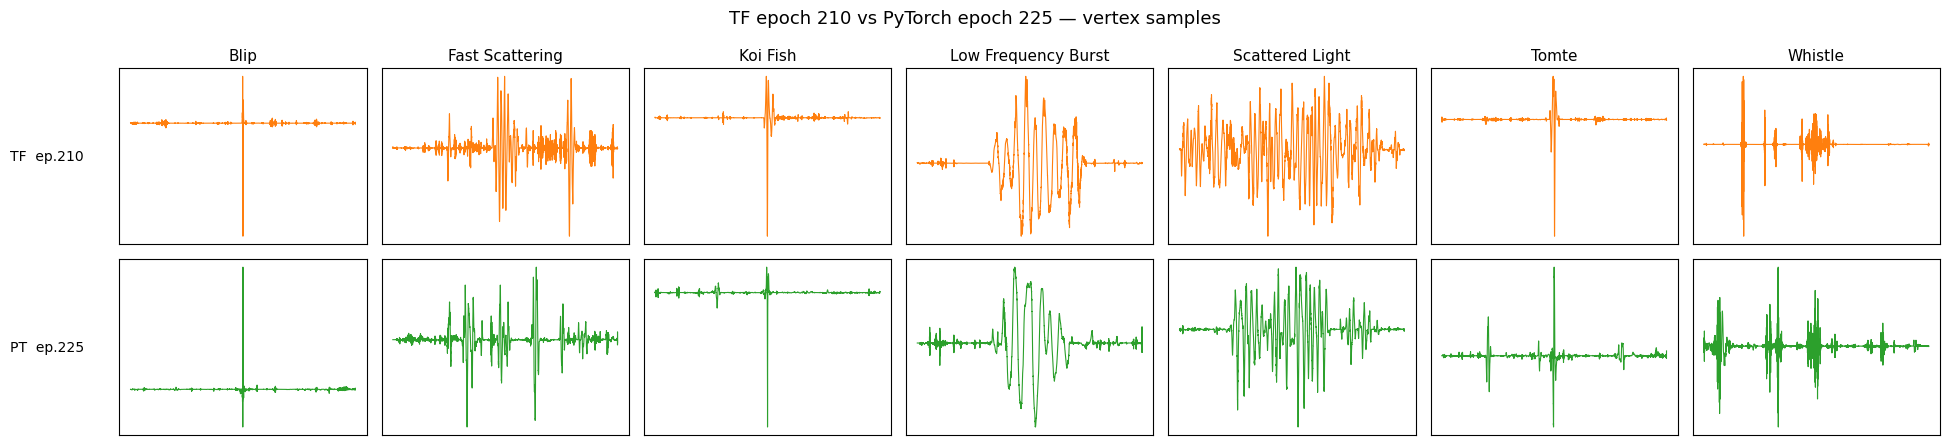

In [12]:
COMPARE_PT_EPOCH = 225   # ← change to 200, 225, etc.

ckpt_compare = PYTORCH_WEIGHTS_DIR / f"generator_{COMPARE_PT_EPOCH}.pt"
gen_compare = Generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES)
gen_compare.load_state_dict(torch.load(ckpt_compare, map_location="cpu"))
gen_compare.eval()

with torch.no_grad():
    noise_v  = torch.randn(NUM_CLASSES, NOISE_DIM)
    class_vecs = torch.eye(NUM_CLASSES, dtype=torch.float32)
    signals_pt_compare = gen_compare(noise_v, class_vecs).numpy()

# Generate one TF vertex sample per class
if TF_AVAILABLE:
    noise_tf_v   = np.random.randn(NUM_CLASSES, NOISE_DIM).astype("float32")
    signals_tf_v = tf_generator.predict([noise_tf_v, np.eye(NUM_CLASSES, dtype="float32")], verbose=0)
else:
    signals_tf_v = None

# ── Plot: TF row on top, PyTorch row below ────────────────────────────────────
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(2.8 * NUM_CLASSES, 4.5))

rows = [
    (signals_tf_v,        "TF  ep.210", "C1"),
    (signals_pt_compare,  f"PT  ep.{COMPARE_PT_EPOCH}", "C2"),
]
for row_idx, (signals, label, color) in enumerate(rows):
    if signals is None:
        for ax in axes[row_idx]: ax.axis("off")
        continue
    for col, (sig, lbl) in enumerate(zip(signals, LABEL_ORDER)):
        ax = axes[row_idx, col]
        ax.plot(sig, lw=0.8, color=color)
        ax.set_xticks([]); ax.set_yticks([])
        if row_idx == 0:
            ax.set_title(lbl.replace("_", " "), fontsize=11)
        if col == 0:
            ax.set_ylabel(label, fontsize=10, rotation=0, labelpad=52, va="center")

plt.suptitle(f"TF epoch 210 vs PyTorch epoch {COMPARE_PT_EPOCH} — vertex samples", fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"tf_vs_pt_ep{COMPARE_PT_EPOCH}.pdf", bbox_inches="tight")
plt.show()

## 4. Waveform Comparison

Side-by-side grid: rows = glitch classes, columns = Real / TF / PyTorch.

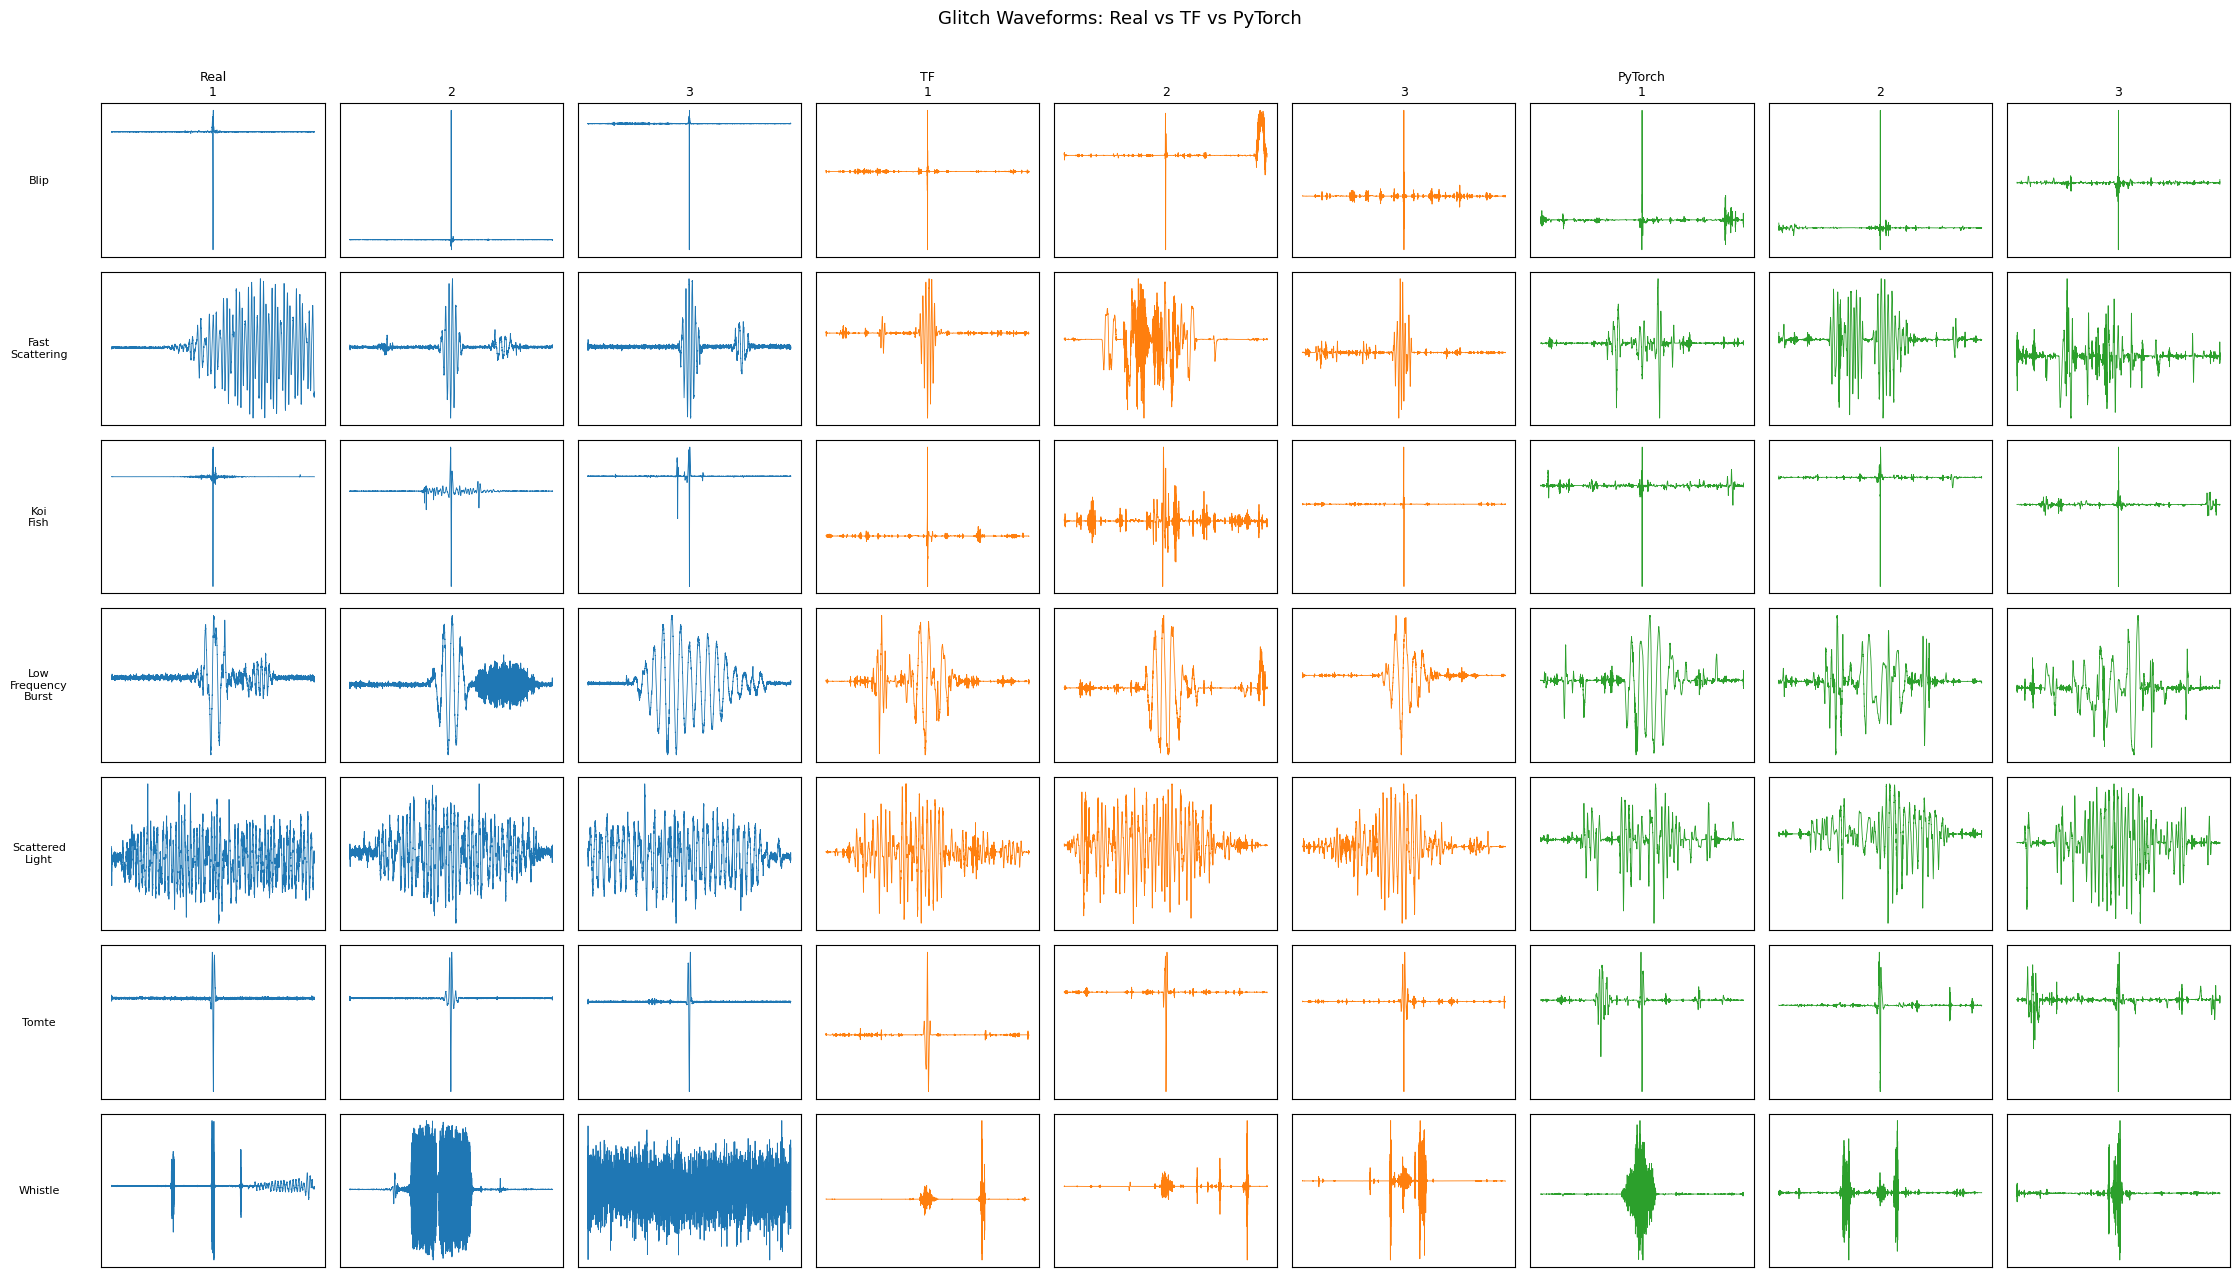

In [13]:
def plot_comparison_grid(sources, labels, n_examples=5, save_name=None):
    """
    sources : list of (X, y, title, color)
    labels  : class label order
    """
    n_sources = len(sources)
    n_classes = len(labels)
    fig, axes = plt.subplots(
        n_classes, n_sources * n_examples,
        figsize=(2.5 * n_sources * n_examples, 1.8 * n_classes)
    )

    for col_group, (X, y, title, color) in enumerate(sources):
        if X is None:
            continue
        for row, lbl in enumerate(labels):
            idx = np.where(y == lbl)[0]
            chosen = np.random.choice(idx, min(n_examples, len(idx)), replace=False)
            for j, ci in enumerate(chosen):
                col = col_group * n_examples + j
                ax = axes[row, col]
                ax.plot(X[ci], lw=0.6, color=color)
                ax.set_xticks([])
                ax.set_yticks([])
                if row == 0:
                    ax.set_title(f"{title}\n{j+1}" if j == 0 else str(j + 1), fontsize=9)
                if col == 0:
                    ax.set_ylabel(lbl.replace("_", "\n"), fontsize=8,
                                  rotation=0, labelpad=45, va="center")

    plt.suptitle("Glitch Waveforms: Real vs TF vs PyTorch", fontsize=13, y=1.01)
    plt.tight_layout()
    if save_name:
        plt.savefig(PLOTS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    plt.show()


sources = [
    (X_real,    y_real,    "Real",    "C0"),
    (X_fake_tf, y_fake_tf, "TF",      "C1"),
    (X_fake_pt, y_fake_pt, "PyTorch", "C2"),
]
plot_comparison_grid(sources, LABEL_ORDER, n_examples=3, save_name="waveform_comparison_grid")

## 5. UMAP Dimensionality Reduction

Joint 3D UMAP embedding of real + TF-generated + PyTorch-generated signals.
Uses a random subsample per class to keep the computation tractable.

In [14]:
# ── Subsample for UMAP ────────────────────────────────────────────────────────
N_UMAP = 300   # samples per class per source

def subsample(X, y, label_order, n):
    idx = []
    for lbl in label_order:
        cls_idx = np.where(y == lbl)[0]
        idx.extend(np.random.choice(cls_idx, min(n, len(cls_idx)), replace=False))
    return X[idx], y[idx]

chunks_X, chunks_y, chunks_domain = [], [], []

X_r_sub, y_r_sub = subsample(X_real, y_real, LABEL_ORDER, N_UMAP)
chunks_X.append(X_r_sub); chunks_y.append(y_r_sub)
chunks_domain.extend(["Real"] * len(X_r_sub))

if TF_AVAILABLE:
    X_tf_sub, y_tf_sub = subsample(X_fake_tf, y_fake_tf, LABEL_ORDER, N_UMAP)
    chunks_X.append(X_tf_sub); chunks_y.append(y_tf_sub)
    chunks_domain.extend(["TF"] * len(X_tf_sub))

if PT_AVAILABLE:
    X_pt_sub, y_pt_sub = subsample(X_fake_pt, y_fake_pt, LABEL_ORDER, N_UMAP)
    chunks_X.append(X_pt_sub); chunks_y.append(y_pt_sub)
    chunks_domain.extend(["PyTorch"] * len(X_pt_sub))

X_all = np.concatenate(chunks_X, axis=0)
y_all = np.concatenate(chunks_y, axis=0)
domain_all = np.array(chunks_domain)

print(f"UMAP input: {X_all.shape}  (total samples)")

UMAP input: (3500, 8192)  (total samples)


In [15]:
# ── Fit UMAP ─────────────────────────────────────────────────────────────────
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.3,
    metric="euclidean",
    random_state=42,
)
embedding = reducer.fit_transform(X_all)
print(f"Embedding shape: {embedding.shape}")

/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Embedding shape: (3500, 3)


In [16]:
# ── Remove outliers (IQR-based on per-axis 1st/99th percentile) ───────────────
def remove_outliers(emb, pct=1):
    lo = np.percentile(emb, pct, axis=0)
    hi = np.percentile(emb, 100 - pct, axis=0)
    mask = np.all((emb >= lo) & (emb <= hi), axis=1)
    return mask

mask = remove_outliers(embedding, pct=1)
emb_clean     = embedding[mask]
y_clean       = y_all[mask]
domain_clean  = domain_all[mask]
print(f"After outlier removal: {emb_clean.shape[0]} / {embedding.shape[0]} points")

After outlier removal: 3290 / 3500 points


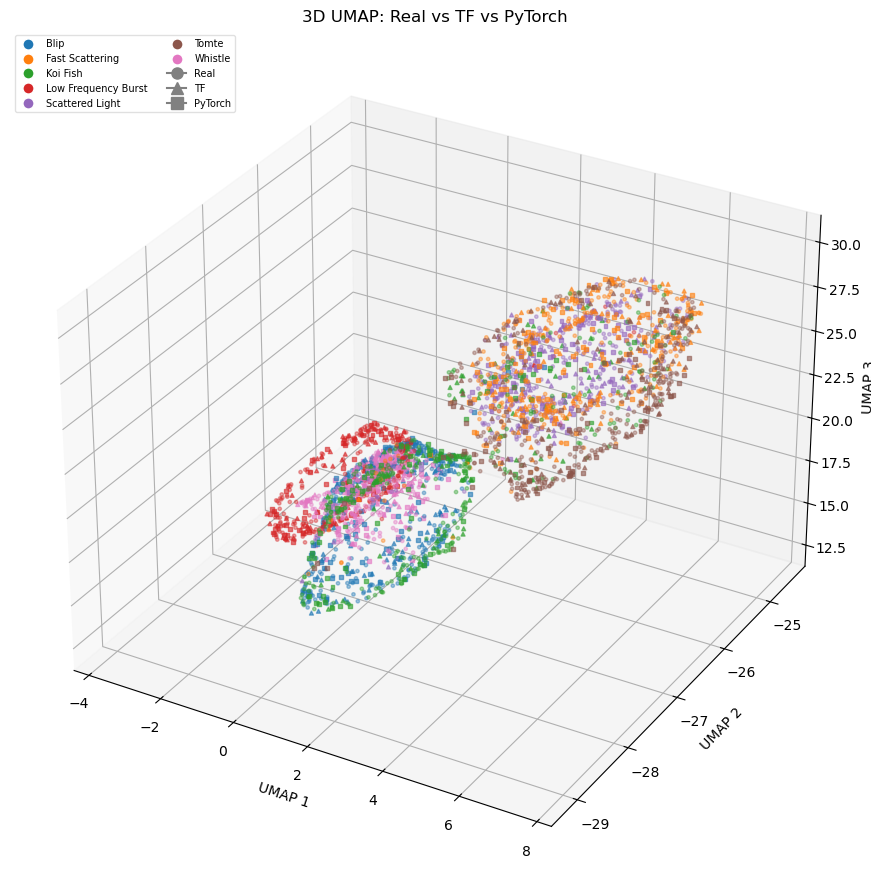

In [17]:
# ── 3D UMAP plot ──────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

CLASS_COLORS = dict(zip(LABEL_ORDER, [f"C{i}" for i in range(len(LABEL_ORDER))]))
DOMAIN_MARKERS = {"Real": "o", "TF": "^", "PyTorch": "s"}
DOMAIN_SIZES   = {"Real": 6,  "TF": 8,   "PyTorch": 8}
DOMAIN_ALPHA   = {"Real": 0.4,"TF": 0.6, "PyTorch": 0.6}

fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(111, projection="3d")

for domain in ["Real", "TF", "PyTorch"]:
    if domain not in domain_clean:
        continue
    for lbl in LABEL_ORDER:
        mask_d = (domain_clean == domain) & (y_clean == lbl)
        if mask_d.sum() == 0:
            continue
        ax.scatter(
            emb_clean[mask_d, 0], emb_clean[mask_d, 1], emb_clean[mask_d, 2],
            c=CLASS_COLORS[lbl],
            marker=DOMAIN_MARKERS[domain],
            s=DOMAIN_SIZES[domain],
            alpha=DOMAIN_ALPHA[domain],
            label=f"{lbl} ({domain})",
        )

# Build compact legend: one entry per class (color) + one per domain (marker)
class_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=CLASS_COLORS[lbl],
           markersize=8, label=lbl.replace("_", " "))
    for lbl in LABEL_ORDER
]
domain_handles = [
    Line2D([0], [0], marker=DOMAIN_MARKERS[d], color="grey",
           markersize=8, label=d)
    for d in DOMAIN_MARKERS if d in domain_clean
]
ax.legend(handles=class_handles + domain_handles,
          loc="upper left", fontsize=7, ncol=2, framealpha=0.6)

ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.set_zlabel("UMAP 3")
ax.set_title("3D UMAP: Real vs TF vs PyTorch")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "umap_3d_comparison.pdf", bbox_inches="tight")
plt.show()

## 6. Gravity Spy Classification

Classifies the generated signals using the Gravity Spy CNN.

**Requirements:** `gengli`, `gwpy`, `gravityspy` and access to an online GW frame channel.
Adjust the configuration block below before running.

In [45]:
# ── Configuration ─────────────────────────────────────────────────────────────
IFO            = "H1"
SRATE          = 4096
GW_START       = 1262540000       # GPS start for background noise segment
GW_END         = GW_START + 40
CHANNEL        = f"{IFO}:GDS-CALIB_STRAIN"
PATH_TO_MODEL  = PROJECT_ROOT / "models" / "sidd-cqg-paper-O3-model.h5"
PATH_TO_REPO   = "/home/meesde.boer/gw_learn/GravitySpy/"  # path on CIT (only needed for imports)
NUM_CLASSIFY   = 10              # signals to classify per class
SNR_TARGET     = 50

In [19]:
import sys, os
sys.path.insert(0, PATH_TO_REPO)

import numpy as np
from tqdm import tqdm
from gwpy.timeseries import TimeSeries
from gravityspy.classify import classify
import pandas as pd
from cdvgan.utils import whitened_snr_scaling


/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1
INFO:panoptes_client:libmagic not operational, likely due to lack of shared libraries. Media MIME type determination will be based on file extensions.


In [49]:
_bg_cache = PLOTS_DIR / f"strain_bg_{GW_START}_{GW_END}.hdf5"

try:
    strain_bg = TimeSeries.read(_bg_cache, format="hdf5")
    print(f"Loaded background from cache: {_bg_cache}")
except Exception:
    strain_bg = TimeSeries.fetch_open_data("H1", GW_START, GW_END)
    strain_bg = strain_bg.resample(SRATE)
    strain_bg.write(_bg_cache, format="hdf5", overwrite=True)
    print(f"Fetched and cached background: {_bg_cache}")

print(f"Background: {strain_bg.duration} s at {strain_bg.sample_rate}")


Loaded background from cache: /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/strain_bg_1262540000_1262540040.hdf5
Background: 40.0 s s at 4096.0 Hz


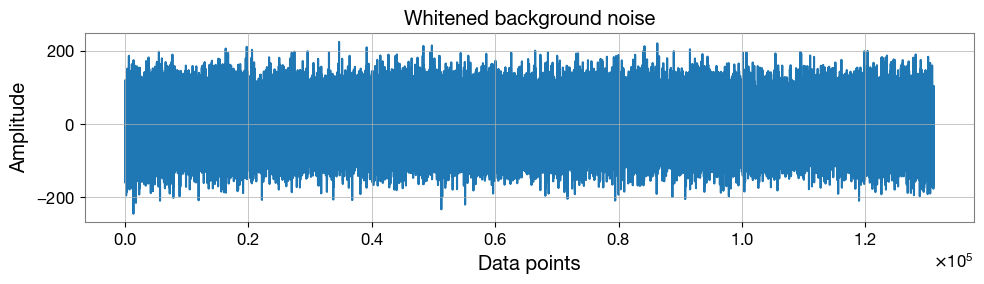

In [50]:
from pycbc.types import TimeSeries as PyCBCTimeSeries
import numpy as np
import matplotlib.pyplot as plt

# Convert to pycbc TimeSeries if not already (gwpy uses .dt/.t0, pycbc uses .delta_t/.start_time)
if hasattr(strain_bg, "delta_t"):
    strain_pycbc = strain_bg  # already pycbc
else:
    strain_pycbc = PyCBCTimeSeries(
        np.asarray(strain_bg, dtype="float64"),
        delta_t=1.0 / SRATE,
        epoch=GW_START,
    )

white_noise, psd = strain_pycbc.whiten(
    len(strain_pycbc) / (2 * SRATE),
    len(strain_pycbc) / (4 * SRATE),
    remove_corrupted=False,
    return_psd=True,
)

plt.figure(figsize=(10, 3))
plt.plot(white_noise[SRATE * 4 : -SRATE * 4])
plt.xlabel("Data points")
plt.ylabel("Amplitude")
plt.title("Whitened background noise")
plt.tight_layout()
plt.show()

In [77]:
import sys, os, warnings, logging

# ── Suppress noisy output from the classification stack ──────────────────────
warnings.filterwarnings("ignore")
logging.getLogger("gravityspy").setLevel(logging.ERROR)
logging.getLogger("gwpy").setLevel(logging.ERROR)
logging.getLogger("astropy").setLevel(logging.ERROR)
logging.getLogger("tensorflow").setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

sys.path.insert(0, PATH_TO_REPO)

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from gwpy.timeseries import TimeSeries as GWpyTimeSeries
from gravityspy.classify import classify
import pandas as pd
from cdvgan.utils import whitened_snr_scaling

INIT_TIME  = -20
EVENT_TIME = 0

def _inject_and_wrap(glitch, white_noise):
    """Direct array injection at midpoint → gwpy TimeSeries (t0=INIT_TIME)."""
    len_glitch = len(glitch)
    id_start   = len(white_noise) // 2 - len_glitch // 2
    injected   = white_noise.copy()
    injected[id_start:id_start + len_glitch] += glitch
    return GWpyTimeSeries(injected, t0=INIT_TIME, sample_rate=SRATE, name=CHANNEL)

def classify_generated_signals(X_gen, y_gen, label_order, tag, white_noise):
    """Inject generated signals into whitened background and classify with Gravity Spy."""
    total = sum(min(NUM_CLASSIFY, int((y_gen == lbl).sum())) for lbl in label_order)
    rows = []
    _prev_backend = plt.get_backend()
    plt.switch_backend("agg")
    try:
        with tqdm(total=total, desc=f"Classifying [{tag}]", unit="glitch") as pbar:
            for lbl in label_order:
                cls_idx = np.where(y_gen == lbl)[0]
                chosen  = np.random.choice(cls_idx, min(NUM_CLASSIFY, len(cls_idx)), replace=False)
                for i in chosen:
                    glitch      = whitened_snr_scaling(X_gen[i], SNR_TARGET, srate=SRATE)
                    glitch_ts   = _inject_and_wrap(glitch, white_noise)
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        result = classify(EVENT_TIME, CHANNEL, str(PATH_TO_MODEL),
                                          timeseries=glitch_ts)
                    rows.append({"true_label": lbl,
                                 "pred_label": result["ml_label"].value[0],
                                 "confidence": result["ml_confidence"].value[0],
                                 "tag": tag})
                    pbar.set_postfix({"class": lbl, "done": len(rows)})
                    pbar.update(1)
    finally:
        plt.switch_backend(_prev_backend)
    return pd.DataFrame(rows)

df_tf = classify_generated_signals(X_fake_tf, y_fake_tf, LABEL_ORDER, "TF", white_noise) \
        if TF_AVAILABLE else None
# df_pt = classify_generated_signals(X_fake_pt, y_fake_pt, LABEL_ORDER, "PyTorch", white_noise) \
#         if PT_AVAILABLE else None

if df_tf is not None: df_tf.to_csv(PLOTS_DIR / "gspy_results_tf.csv", index=False)
# if df_pt is not None: df_pt.to_csv(PLOTS_DIR / "gspy_results_pt.csv", index=False)

Classifying [TF]:   0%|          | 0/700 [00:00<?, ?glitch/s]

In [62]:
# import numpy as np
# import matplotlib.pyplot as plt
# from cdvgan.utils import whitened_snr_scaling

# N_BLIP   = 3
# PLOT_DUR = 1.0  # seconds either side of t=0

# blip_idx_tf = np.where(y_fake_tf == "Blip")[0]
# blip_idx_pt = np.where(y_fake_pt == "Blip")[0]
# chosen_tf = np.random.choice(blip_idx_tf, min(N_BLIP, len(blip_idx_tf)), replace=False)
# chosen_pt = np.random.choice(blip_idx_pt, min(N_BLIP, len(blip_idx_pt)), replace=False)

# fig, axes = plt.subplots(2, N_BLIP, figsize=(4 * N_BLIP, 7))

# for col, (tf_i, pt_i) in enumerate(zip(chosen_tf, chosen_pt)):
#     for row, (X_src, idx, label) in enumerate([
#         (X_fake_tf, tf_i, "TF ep.210"),
#         (X_fake_pt, pt_i, f"PT ep.{PYTORCH_EPOCH}"),
#     ]):
#         glitch    = whitened_snr_scaling(X_src[idx], SNR_TARGET, srate=SRATE)
#         glitch_ts = _inject_and_wrap(glitch, white_noise)

#         cropped = glitch_ts.crop(EVENT_TIME - PLOT_DUR, EVENT_TIME + PLOT_DUR)
#         qgram   = cropped.q_transform(frange=(10, 2048),
#                                       outseg=(EVENT_TIME - PLOT_DUR, EVENT_TIME + PLOT_DUR))

#         times = qgram.times.value - EVENT_TIME
#         freqs = qgram.frequencies.value

#         ax = axes[row, col]
#         ax.pcolormesh(times, freqs, qgram.value.T, cmap="viridis", shading="auto")
#         ax.set_yscale("log")
#         ax.set_xlabel("Time − t₀ (s)")
#         ax.set_ylabel("Frequency (Hz)")
#         ax.set_title(f"{label} — Blip {col+1}", fontsize=10)

# plt.suptitle("Q-transform: Blip injections (TF vs PyTorch)", fontsize=13)
# plt.tight_layout()
# plt.savefig(PLOTS_DIR / "blip_qtransform.pdf", bbox_inches="tight")
# plt.show()

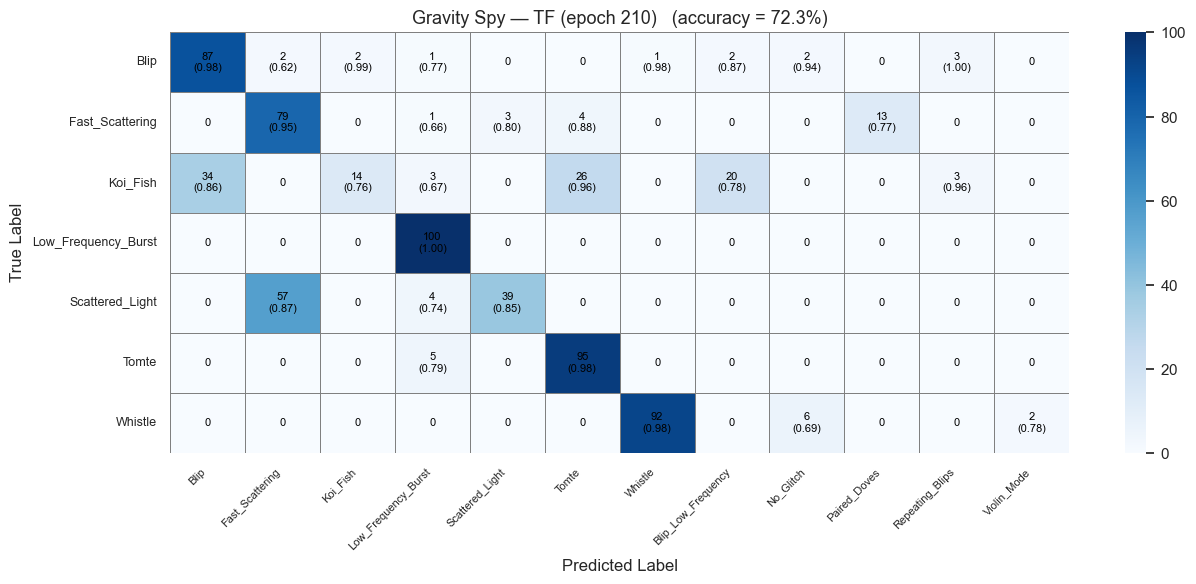

TF (epoch 210) accuracy: 0.723


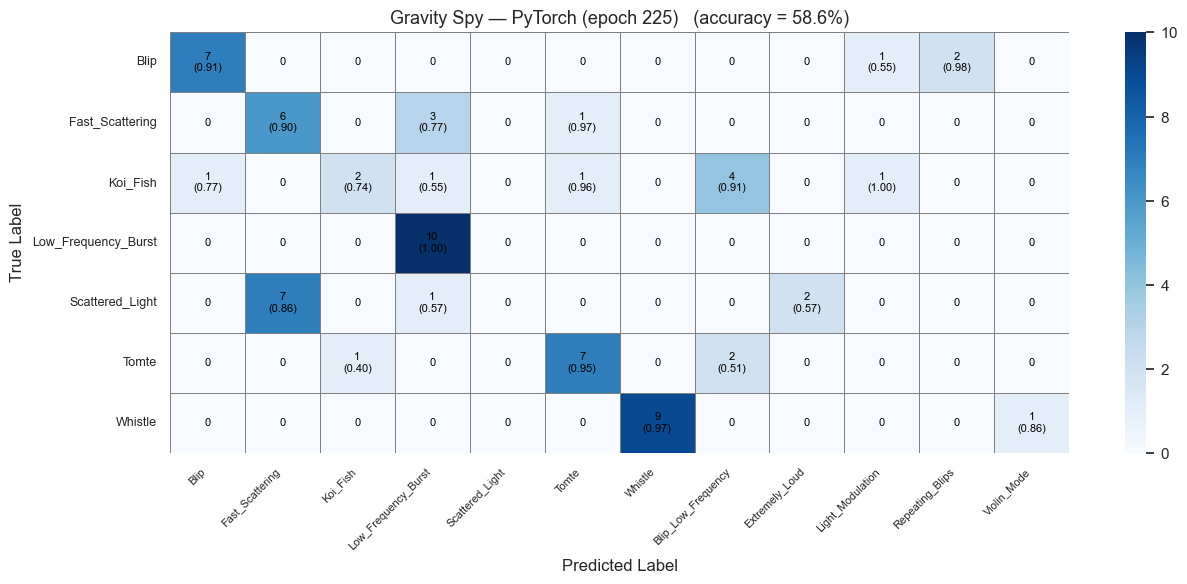

PyTorch (epoch 225) accuracy: 0.586


In [78]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_confusion(df, tag, save_name):
    if df is None:
        print(f"No results for {tag}")
        return None

    df = df[df["pred_label"] != "Error"]

    # Columns: true classes first, then any extra classes Gravity Spy predicted
    pred_all = sorted(df["pred_label"].unique())
    for lbl in LABEL_ORDER:
        if lbl not in pred_all:
            pred_all.append(lbl)
    pred_cols = (
        [lbl for lbl in LABEL_ORDER if lbl in pred_all] +
        [lbl for lbl in pred_all if lbl not in LABEL_ORDER]
    )

    count_matrix = pd.DataFrame(0,   index=LABEL_ORDER, columns=pred_cols)
    conf_accum   = {(t, p): [] for t in LABEL_ORDER for p in pred_cols}

    for t, p, c in zip(df["true_label"], df["pred_label"], df["confidence"]):
        if t in LABEL_ORDER and p in pred_cols:
            count_matrix.loc[t, p] += 1
            conf_accum[(t, p)].append(c)

    # Annotation: "count\n(mean_conf)" or "0"
    annot = pd.DataFrame("", index=LABEL_ORDER, columns=pred_cols)
    for t in LABEL_ORDER:
        for p in pred_cols:
            n = count_matrix.loc[t, p]
            if n == 0:
                annot.loc[t, p] = "0"
            else:
                m = np.mean(conf_accum[(t, p)])
                annot.loc[t, p] = f"{n}\n({m:.2f})"

    acc = np.trace(count_matrix.values) / count_matrix.values.sum()

    fig_w = max(10, len(pred_cols) * 1.1)
    plt.figure(figsize=(fig_w, 6))
    sns.set(style="whitegrid", font_scale=1.0)
    ax = sns.heatmap(
        count_matrix,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        linecolor="gray",
        annot_kws={"size": 8, "color": "black"},
    )
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title(f"Gravity Spy — {tag}   (accuracy = {acc:.1%})", fontsize=13)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    plt.show()
    print(f"{tag} accuracy: {acc:.3f}")
    return acc

acc_tf = plot_confusion(df_tf, "TF (epoch 210)", "gspy_confusion_tf")
acc_pt = plot_confusion(df_pt, f"PyTorch (epoch {PYTORCH_EPOCH})", "gspy_confusion_pt")

## 6b. PyTorch multi-epoch classification (200 / 225 / 250)

In [68]:
import sys, os, warnings, logging

# ── Suppress noisy output from the classification stack ──────────────────────
warnings.filterwarnings("ignore")
logging.getLogger("gravityspy").setLevel(logging.ERROR)
logging.getLogger("gwpy").setLevel(logging.ERROR)
logging.getLogger("astropy").setLevel(logging.ERROR)
logging.getLogger("tensorflow").setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [70]:
import torch
import numpy as np
from cdvgan.model_components import Generator

PT_EVAL_EPOCHS   = [200, 225, 250]
N_PER_CLASS      = 100   # samples per class per epoch

epoch_results = {}   # epoch → DataFrame

for epoch in PT_EVAL_EPOCHS:
    ckpt = PYTORCH_WEIGHTS_DIR / f"generator_{epoch}.pt"
    if not ckpt.exists():
        print(f"[SKIP] generator_{epoch}.pt not found")
        continue

    # ── Load generator ────────────────────────────────────────────────────────
    gen = Generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES)
    gen.load_state_dict(torch.load(ckpt, map_location="cpu"))
    gen.eval()
    print(f"Loaded epoch {epoch}")

    # ── Generate N_PER_CLASS samples per class (overwrite each iteration) ─────
    num_examples     = NUM_CLASSES * N_PER_CLASS
    class_vectors    = np.repeat(np.eye(NUM_CLASSES), N_PER_CLASS, axis=0)
    with torch.no_grad():
        noise_t  = torch.randn(num_examples, NOISE_DIM)
        class_t  = torch.tensor(class_vectors, dtype=torch.float32)
        X_epoch  = gen(noise_t, class_t).numpy()
    y_epoch = np.repeat(LABEL_ORDER, N_PER_CLASS)

    del gen, noise_t, class_t, class_vectors   # free GPU/CPU memory

    # ── Classify ──────────────────────────────────────────────────────────────
    # Temporarily override NUM_CLASSIFY so the shared function uses N_PER_CLASS
    _saved_num_classify = NUM_CLASSIFY
    globals()["NUM_CLASSIFY"] = N_PER_CLASS

    df_epoch = classify_generated_signals(
        X_epoch, y_epoch, LABEL_ORDER, f"PT ep.{epoch}", white_noise
    )

    globals()["NUM_CLASSIFY"] = _saved_num_classify

    del X_epoch, y_epoch   # free generated data before next epoch

    # ── Save CSV ──────────────────────────────────────────────────────────────
    csv_path = PLOTS_DIR / f"gspy_results_pt_ep{epoch}.csv"
    df_epoch.to_csv(csv_path, index=False)
    print(f"Saved → {csv_path}")

    epoch_results[epoch] = df_epoch

print("Done.")

Loaded epoch 200


Classifying [PT ep.200]:   0%|          | 0/700 [00:00<?, ?glitch/s]

Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_ep200.csv
Loaded epoch 225


Classifying [PT ep.225]:   0%|          | 0/700 [00:00<?, ?glitch/s]

Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_ep225.csv
Loaded epoch 250


Classifying [PT ep.250]:   0%|          | 0/700 [00:00<?, ?glitch/s]

Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_ep250.csv
Done.


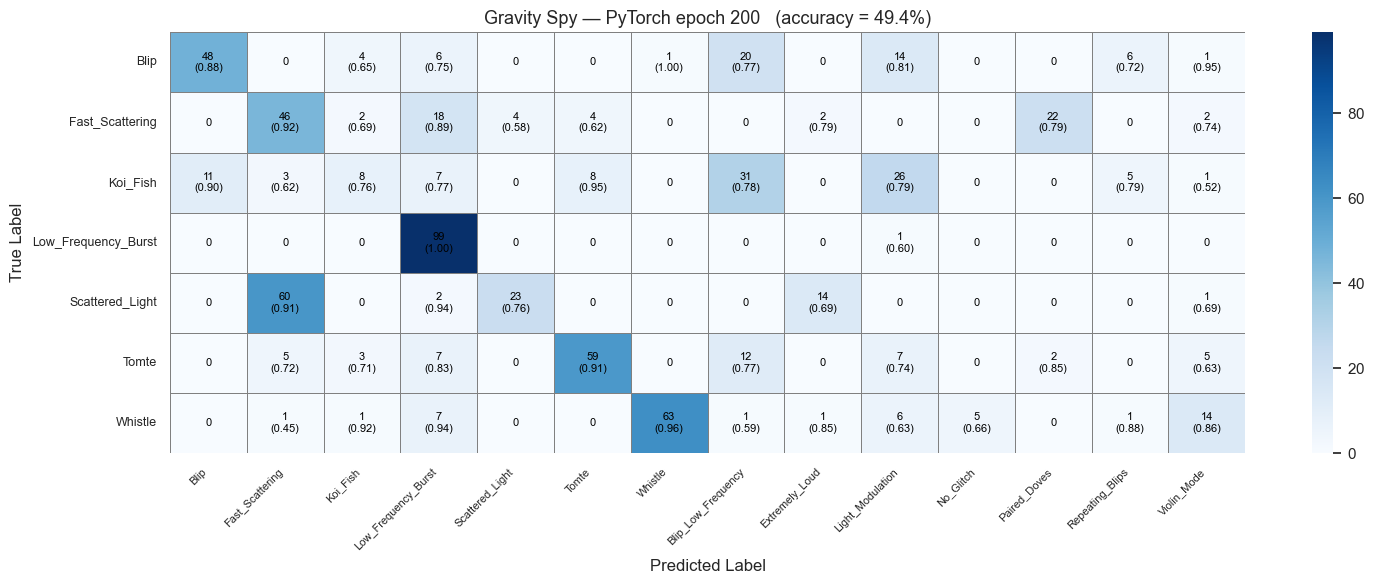

PyTorch epoch 200 accuracy: 0.494


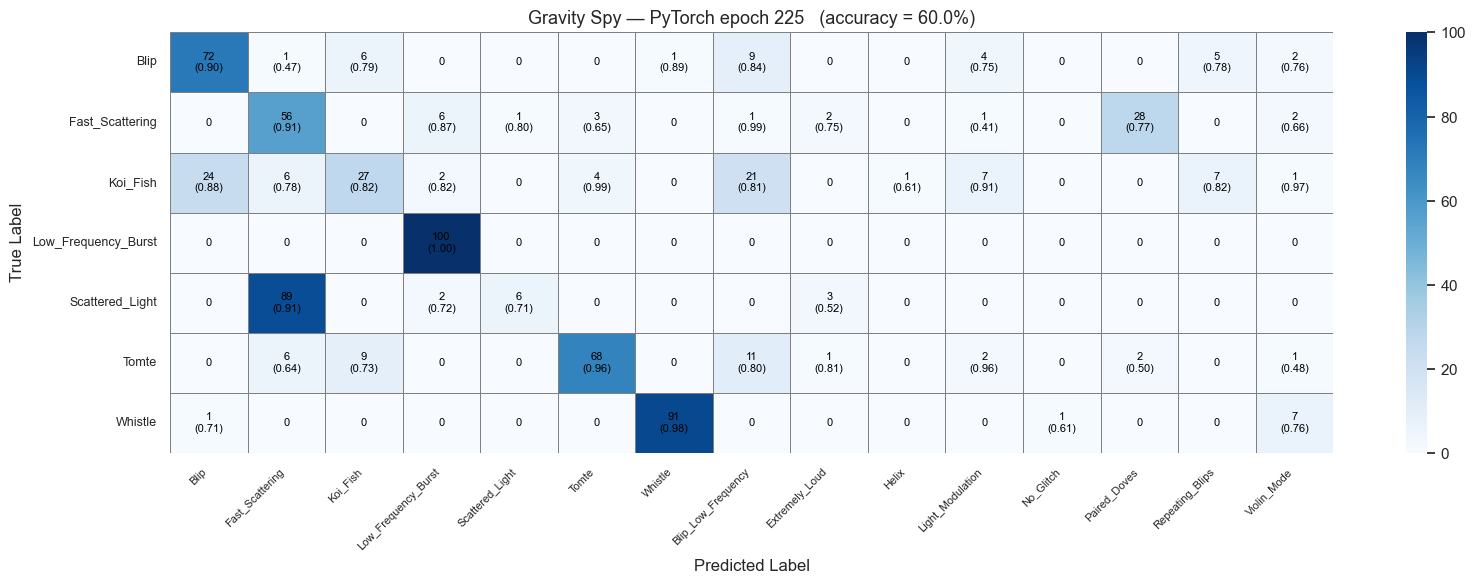

PyTorch epoch 225 accuracy: 0.600


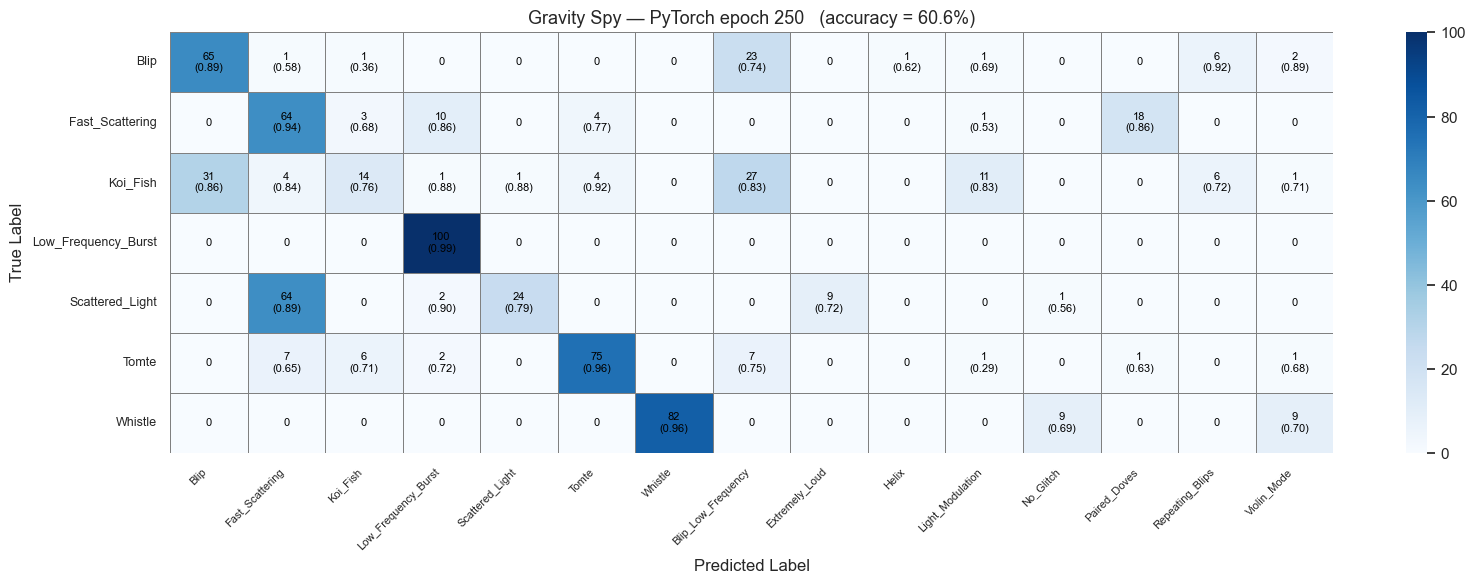

PyTorch epoch 250 accuracy: 0.606


In [71]:
for epoch, df_epoch in epoch_results.items():
    plot_confusion(df_epoch, f"PyTorch epoch {epoch}", f"gspy_confusion_pt_ep{epoch}")

In [73]:
import torch
import numpy as np
from cdvgan.model_components import Generator

PT_EVAL_EPOCHS   = [300, 400, 500]
N_PER_CLASS      = 100   # samples per class per epoch

epoch_results = {}   # epoch → DataFrame

for epoch in PT_EVAL_EPOCHS:
    ckpt = PYTORCH_WEIGHTS_DIR / f"generator_{epoch}.pt"
    if not ckpt.exists():
        print(f"[SKIP] generator_{epoch}.pt not found")
        continue

    # ── Load generator ────────────────────────────────────────────────────────
    gen = Generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES)
    gen.load_state_dict(torch.load(ckpt, map_location="cpu"))
    gen.eval()
    print(f"Loaded epoch {epoch}")

    # ── Generate N_PER_CLASS samples per class (overwrite each iteration) ─────
    num_examples     = NUM_CLASSES * N_PER_CLASS
    class_vectors    = np.repeat(np.eye(NUM_CLASSES), N_PER_CLASS, axis=0)
    with torch.no_grad():
        noise_t  = torch.randn(num_examples, NOISE_DIM)
        class_t  = torch.tensor(class_vectors, dtype=torch.float32)
        X_epoch  = gen(noise_t, class_t).numpy()
    y_epoch = np.repeat(LABEL_ORDER, N_PER_CLASS)

    del gen, noise_t, class_t, class_vectors   # free GPU/CPU memory

    # ── Classify ──────────────────────────────────────────────────────────────
    # Temporarily override NUM_CLASSIFY so the shared function uses N_PER_CLASS
    _saved_num_classify = NUM_CLASSIFY
    globals()["NUM_CLASSIFY"] = N_PER_CLASS

    df_epoch = classify_generated_signals(
        X_epoch, y_epoch, LABEL_ORDER, f"PT ep.{epoch}", white_noise
    )

    globals()["NUM_CLASSIFY"] = _saved_num_classify

    del X_epoch, y_epoch   # free generated data before next epoch

    # ── Save CSV ──────────────────────────────────────────────────────────────
    csv_path = PLOTS_DIR / f"gspy_results_pt_ep{epoch}.csv"
    df_epoch.to_csv(csv_path, index=False)
    print(f"Saved → {csv_path}")

    epoch_results[epoch] = df_epoch

print("Done.")

Loaded epoch 300


Classifying [PT ep.300]:   0%|          | 0/700 [00:00<?, ?glitch/s]

Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_ep300.csv
Loaded epoch 400


Classifying [PT ep.400]:   0%|          | 0/700 [00:00<?, ?glitch/s]

Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_ep400.csv
Loaded epoch 500


Classifying [PT ep.500]:   0%|          | 0/700 [00:00<?, ?glitch/s]

Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_ep500.csv
Done.


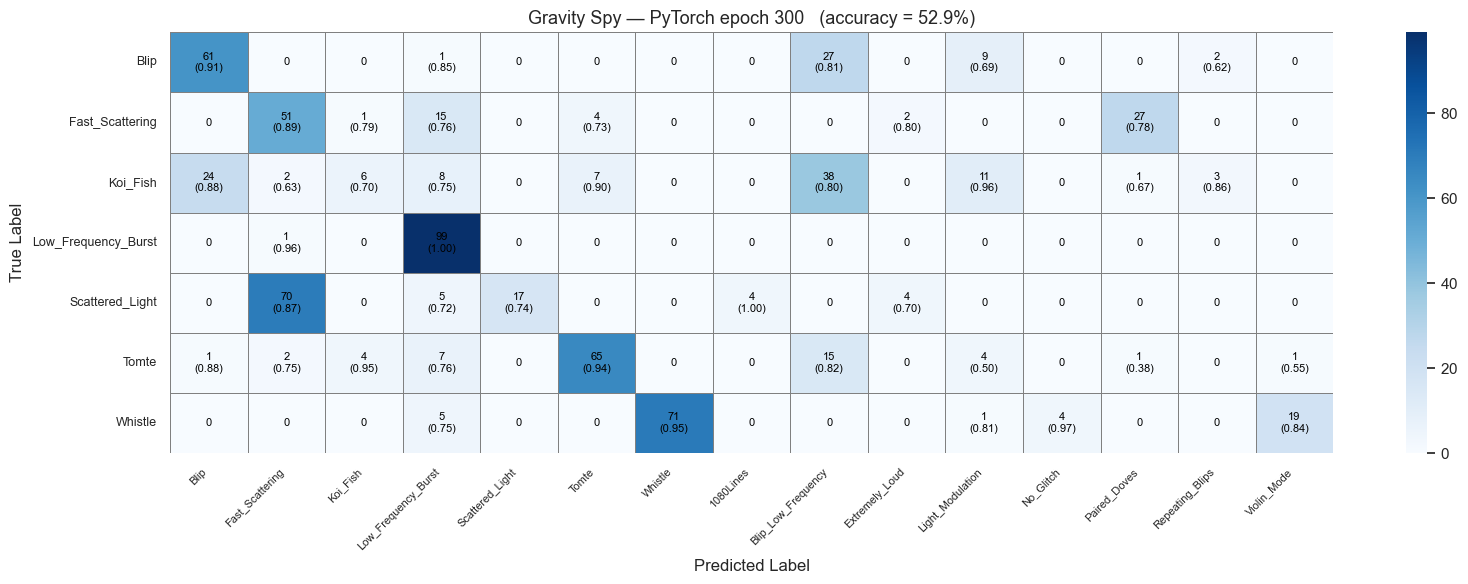

PyTorch epoch 300 accuracy: 0.529


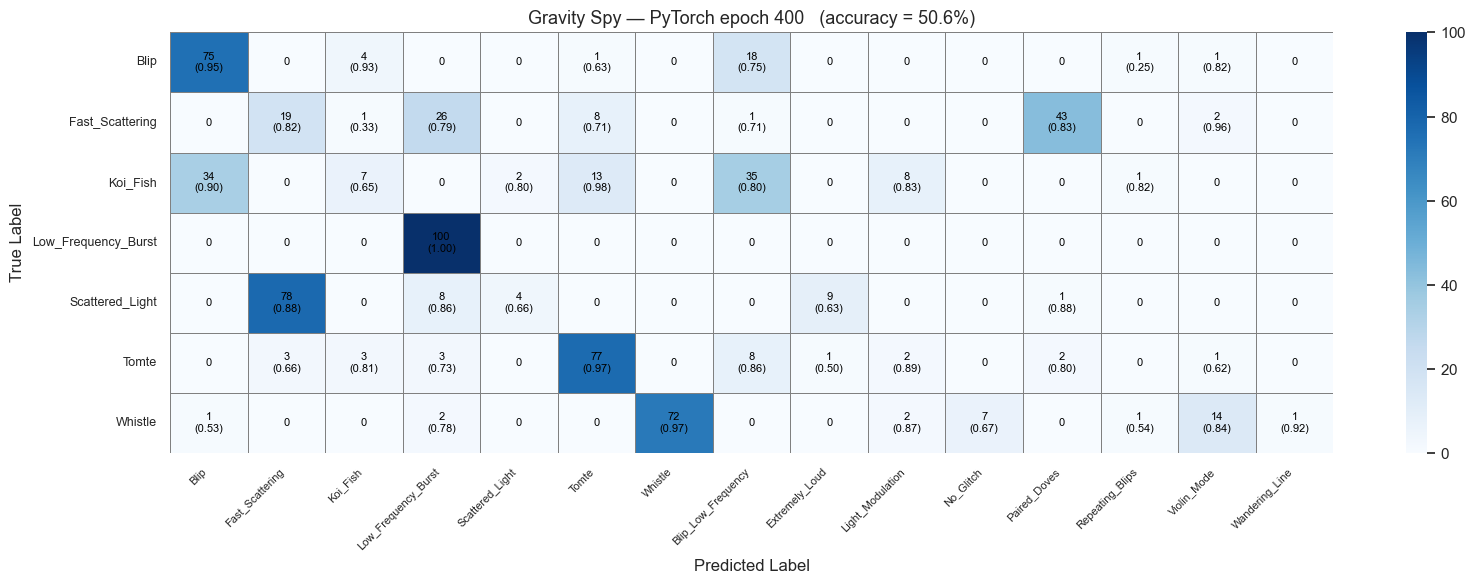

PyTorch epoch 400 accuracy: 0.506


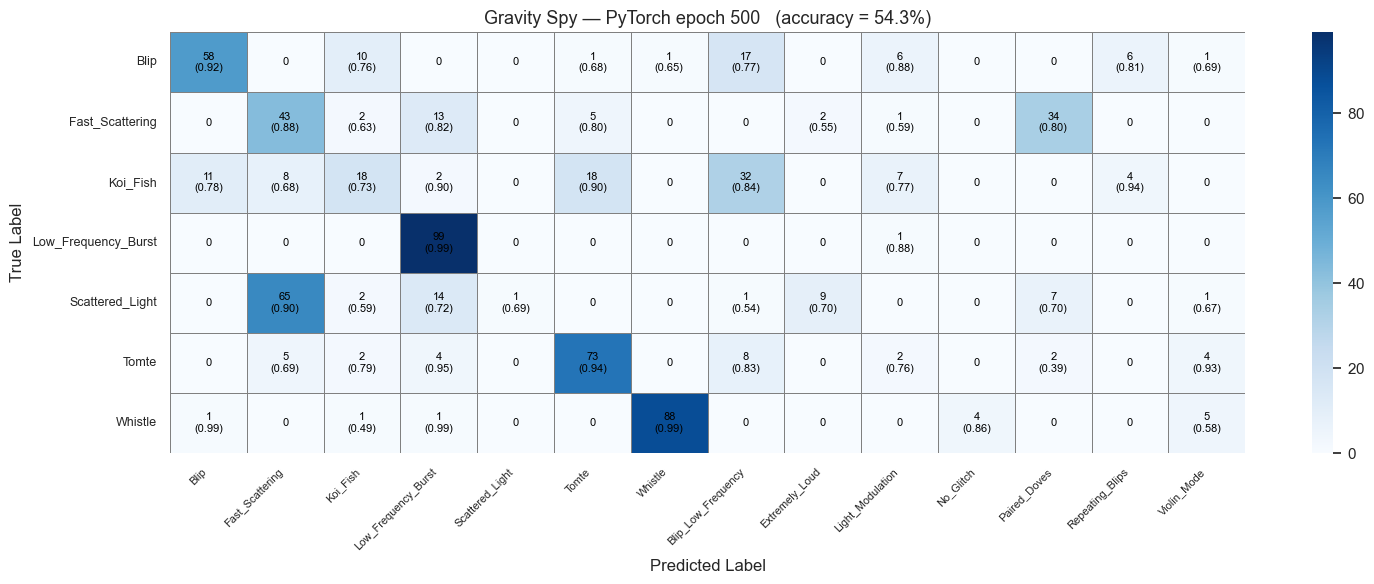

PyTorch epoch 500 accuracy: 0.543


In [76]:
for epoch, df_epoch in epoch_results.items():
    plot_confusion(df_epoch, f"PyTorch epoch {epoch}", f"gspy_confusion_pt_ep{epoch}")

### Load pre-saved classification results

If you have already run the classifier and saved CSV files, use this cell instead.

In [ ]:
for epoch, df_epoch in epoch_results.items():
    plot_confusion(df_epoch, f"PyTorch epoch {epoch}", f"gspy_confusion_pt_ep{epoch}")

In [ ]:
# Uncomment and adjust paths as needed
# df_tf = pd.read_csv(PLOTS_DIR / "gspy_results_tf.csv")
# df_pt = pd.read_csv(PLOTS_DIR / "gspy_results_pt.csv")
# acc_tf = plot_confusion(df_tf, "TF (epoch 210)", "gspy_confusion_tf_loaded")
# acc_pt = plot_confusion(df_pt, f"PyTorch (epoch {PYTORCH_EPOCH})", "gspy_confusion_pt_loaded")

## 6c. PyTorch v2 multi-epoch classification (150 / 200 / 250 / 300 / 400)

Loaded v2 epoch 150


Classifying [PT v2 ep.150]:   0%|          | 0/175 [00:00<?, ?glitch/s]

  → v2 epoch 150 accuracy: 0.589
  Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_v2_ep150.csv
Loaded v2 epoch 200


Classifying [PT v2 ep.200]:   0%|          | 0/175 [00:00<?, ?glitch/s]

  → v2 epoch 200 accuracy: 0.554
  Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_v2_ep200.csv
Loaded v2 epoch 250


...

  → v2 epoch 250 accuracy: 0.383
  Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_v2_ep250.csv
Loaded v2 epoch 300


Classifying [PT v2 ep.300]:   0%|          | 0/175 [00:00<?, ?glitch/s]

  → v2 epoch 300 accuracy: 0.360
  Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_v2_ep300.csv
Loaded v2 epoch 400


Classifying [PT v2 ep.400]:   0%|          | 0/175 [00:00<?, ?glitch/s]

  → v2 epoch 400 accuracy: 0.554
  Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_v2_ep400.csv
Done.


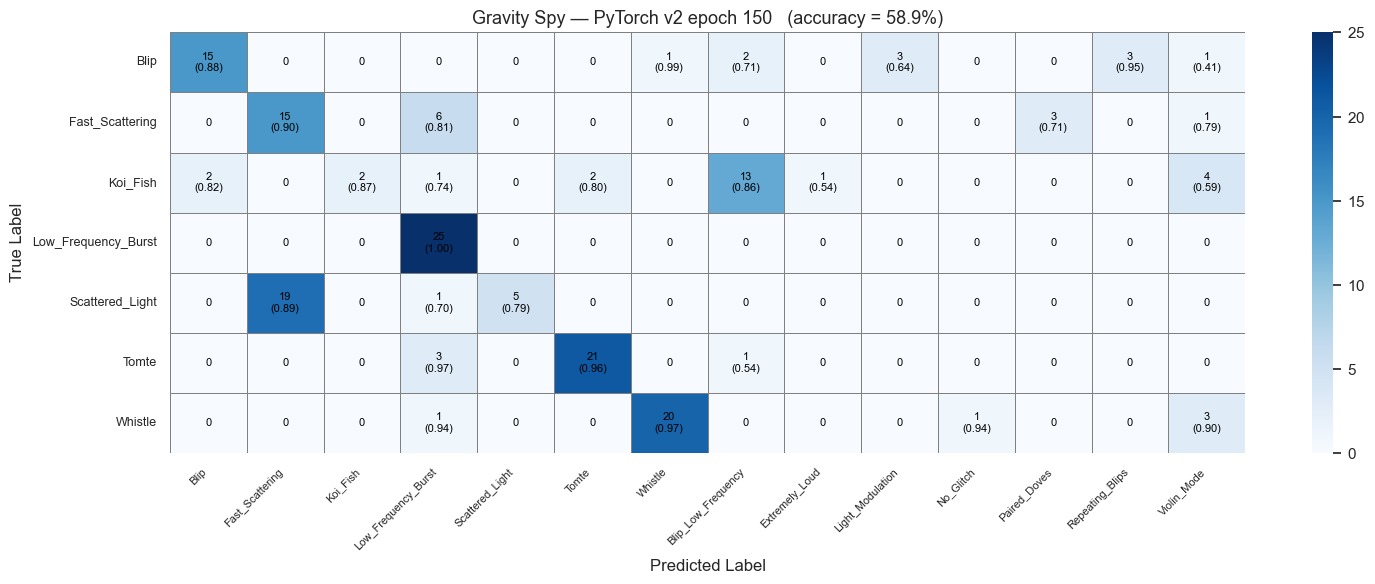

PyTorch v2 epoch 150 accuracy: 0.589


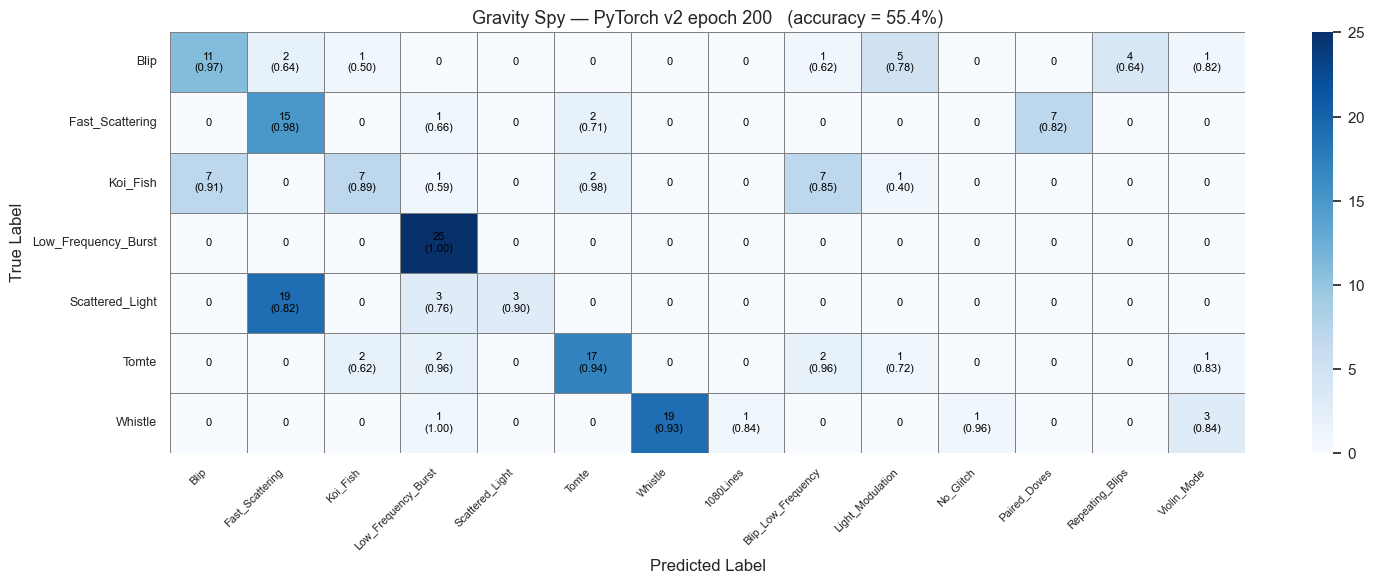

PyTorch v2 epoch 200 accuracy: 0.554


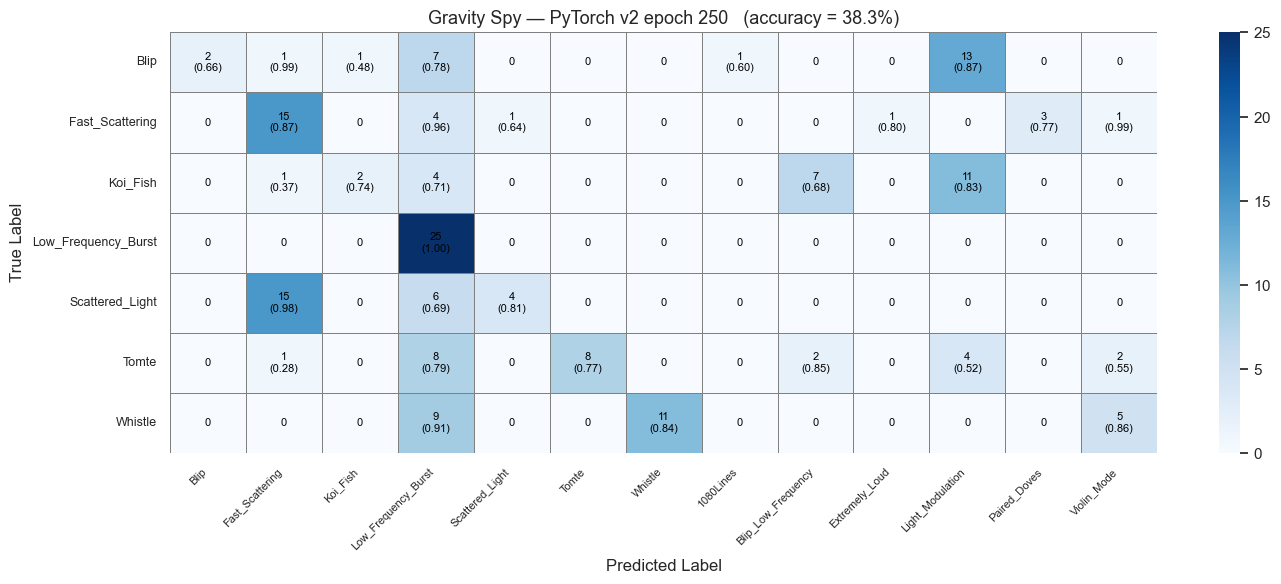

PyTorch v2 epoch 250 accuracy: 0.383


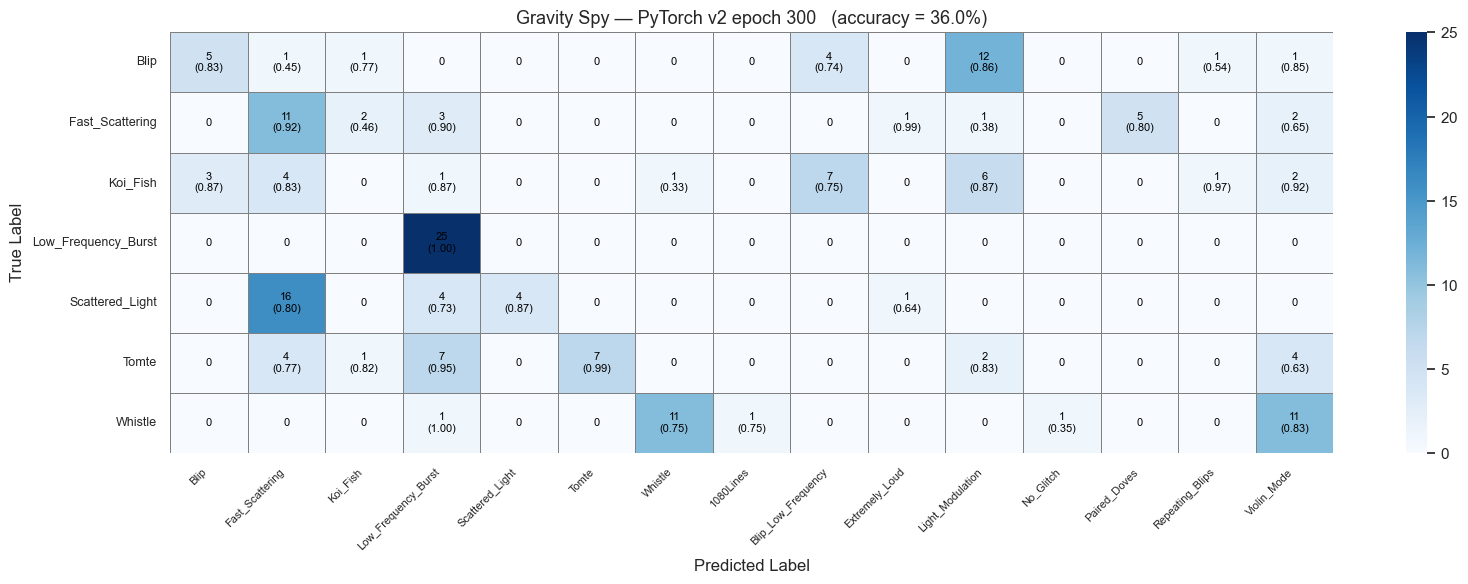

PyTorch v2 epoch 300 accuracy: 0.360


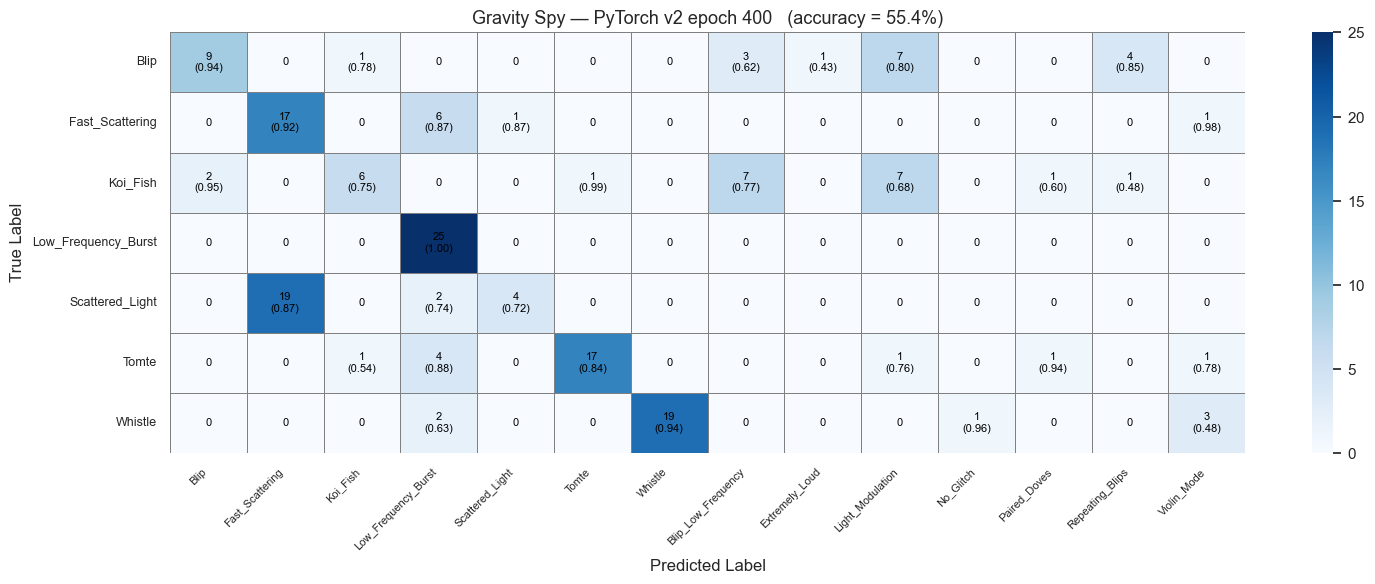

PyTorch v2 epoch 400 accuracy: 0.554


In [79]:
import torch
import numpy as np
from cdvgan.model_components import Generator

V2_WEIGHTS_DIR   = PYTORCH_WEIGHTS_DIR / "v2"
PT_EVAL_EPOCHS_V2 = [150, 200, 250, 300, 400]
N_PER_CLASS_V2   = 25

epoch_results_v2 = {}   # epoch → DataFrame

for epoch in PT_EVAL_EPOCHS_V2:
    ckpt = V2_WEIGHTS_DIR / f"generator_{epoch}.pt"
    if not ckpt.exists():
        print(f"[SKIP] generator_{epoch}.pt not found in {V2_WEIGHTS_DIR}")
        continue

    # ── Load generator ────────────────────────────────────────────────────────
    gen = Generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES)
    gen.load_state_dict(torch.load(ckpt, map_location="cpu"))
    gen.eval()
    print(f"Loaded v2 epoch {epoch}")

    # ── Generate samples ──────────────────────────────────────────────────────
    num_examples  = NUM_CLASSES * N_PER_CLASS_V2
    class_vectors = np.repeat(np.eye(NUM_CLASSES), N_PER_CLASS_V2, axis=0)
    with torch.no_grad():
        noise_t = torch.randn(num_examples, NOISE_DIM)
        class_t = torch.tensor(class_vectors, dtype=torch.float32)
        X_epoch = gen(noise_t, class_t).numpy()
    y_epoch = np.repeat(LABEL_ORDER, N_PER_CLASS_V2)

    del gen, noise_t, class_t, class_vectors

    # ── Classify ──────────────────────────────────────────────────────────────
    _saved_num_classify = NUM_CLASSIFY
    globals()["NUM_CLASSIFY"] = N_PER_CLASS_V2

    df_epoch = classify_generated_signals(
        X_epoch, y_epoch, LABEL_ORDER, f"PT v2 ep.{epoch}", white_noise
    )

    globals()["NUM_CLASSIFY"] = _saved_num_classify
    del X_epoch, y_epoch

    # ── Accuracy ──────────────────────────────────────────────────────────────
    df_clean = df_epoch[df_epoch["pred_label"] != "Error"]
    acc = (df_clean["true_label"] == df_clean["pred_label"]).mean()
    print(f"  → v2 epoch {epoch} accuracy: {acc:.3f}")

    # ── Save CSV ──────────────────────────────────────────────────────────────
    csv_path = PLOTS_DIR / f"gspy_results_pt_v2_ep{epoch}.csv"
    df_epoch.to_csv(csv_path, index=False)
    print(f"  Saved → {csv_path}")

    epoch_results_v2[epoch] = df_epoch

print("Done.")

for epoch, df_epoch in epoch_results_v2.items():
    plot_confusion(df_epoch, f"PyTorch v2 epoch {epoch}", f"gspy_confusion_pt_v2_ep{epoch}")

Loaded v2 epoch 75


Classifying [PT v2 ep.75]:   0%|          | 0/175 [00:00<?, ?glitch/s]

  → v2 epoch 75 accuracy: 0.623
  Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_v2_ep75.csv
Loaded v2 epoch 100


Classifying [PT v2 ep.100]:   0%|          | 0/175 [00:00<?, ?glitch/s]

  → v2 epoch 100 accuracy: 0.514
  Saved → /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/gspy_results_pt_v2_ep100.csv
Done.


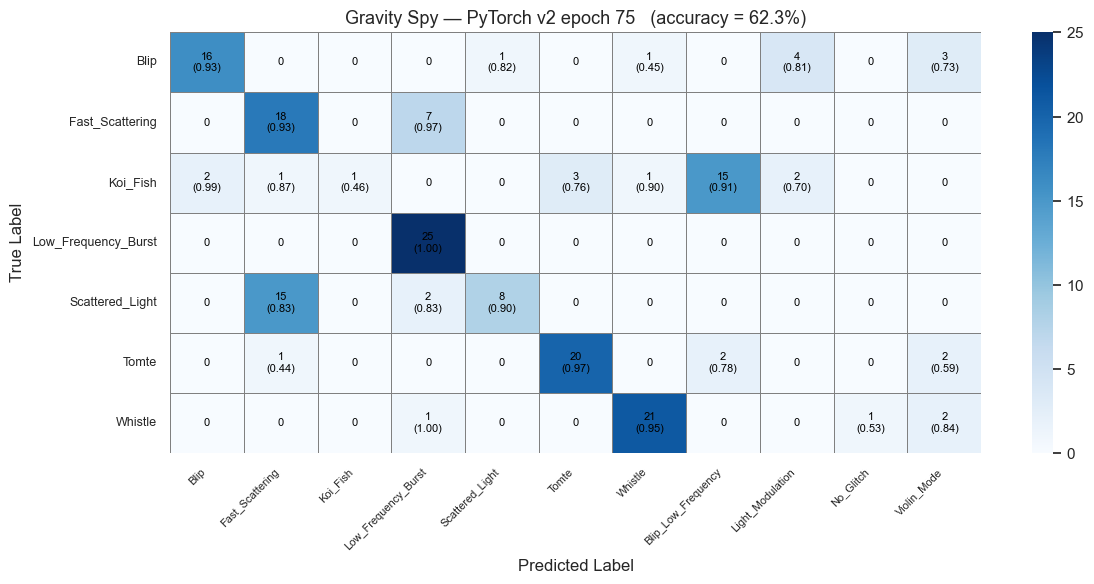

PyTorch v2 epoch 75 accuracy: 0.623


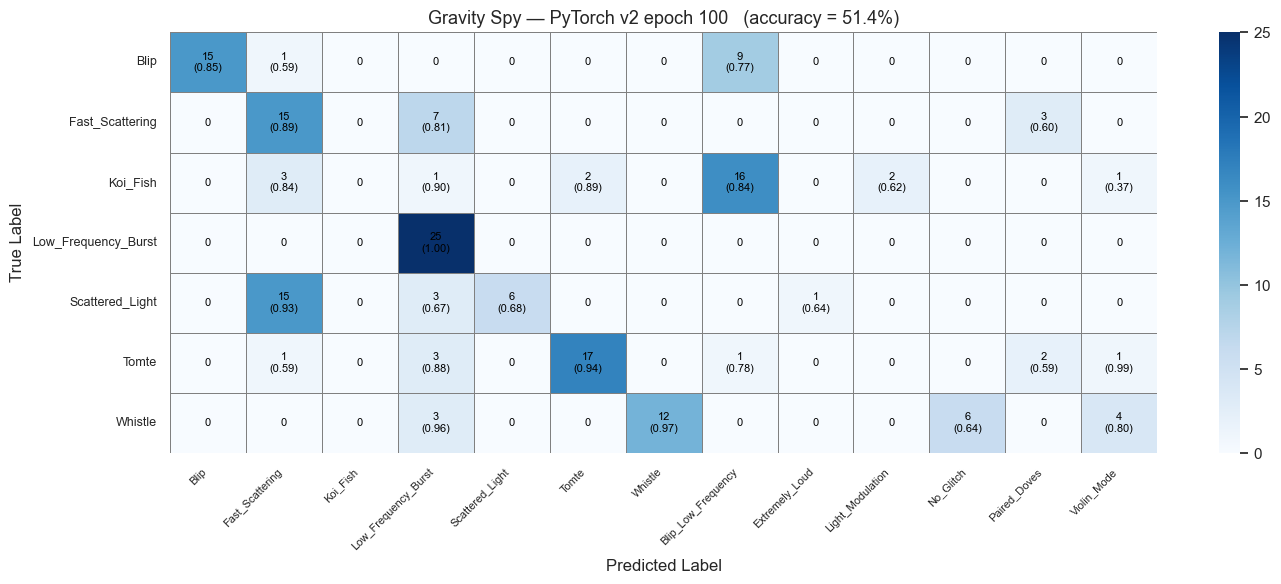

PyTorch v2 epoch 100 accuracy: 0.514


In [80]:
import torch
import numpy as np
from cdvgan.model_components import Generator

V2_WEIGHTS_DIR   = PYTORCH_WEIGHTS_DIR / "v2"
PT_EVAL_EPOCHS_V2 = [75, 100]
N_PER_CLASS_V2   = 25

epoch_results_v2 = {}   # epoch → DataFrame

for epoch in PT_EVAL_EPOCHS_V2:
    ckpt = V2_WEIGHTS_DIR / f"generator_{epoch}.pt"
    if not ckpt.exists():
        print(f"[SKIP] generator_{epoch}.pt not found in {V2_WEIGHTS_DIR}")
        continue

    # ── Load generator ────────────────────────────────────────────────────────
    gen = Generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES)
    gen.load_state_dict(torch.load(ckpt, map_location="cpu"))
    gen.eval()
    print(f"Loaded v2 epoch {epoch}")

    # ── Generate samples ──────────────────────────────────────────────────────
    num_examples  = NUM_CLASSES * N_PER_CLASS_V2
    class_vectors = np.repeat(np.eye(NUM_CLASSES), N_PER_CLASS_V2, axis=0)
    with torch.no_grad():
        noise_t = torch.randn(num_examples, NOISE_DIM)
        class_t = torch.tensor(class_vectors, dtype=torch.float32)
        X_epoch = gen(noise_t, class_t).numpy()
    y_epoch = np.repeat(LABEL_ORDER, N_PER_CLASS_V2)

    del gen, noise_t, class_t, class_vectors

    # ── Classify ──────────────────────────────────────────────────────────────
    _saved_num_classify = NUM_CLASSIFY
    globals()["NUM_CLASSIFY"] = N_PER_CLASS_V2

    df_epoch = classify_generated_signals(
        X_epoch, y_epoch, LABEL_ORDER, f"PT v2 ep.{epoch}", white_noise
    )

    globals()["NUM_CLASSIFY"] = _saved_num_classify
    del X_epoch, y_epoch

    # ── Accuracy ──────────────────────────────────────────────────────────────
    df_clean = df_epoch[df_epoch["pred_label"] != "Error"]
    acc = (df_clean["true_label"] == df_clean["pred_label"]).mean()
    print(f"  → v2 epoch {epoch} accuracy: {acc:.3f}")

    # ── Save CSV ──────────────────────────────────────────────────────────────
    csv_path = PLOTS_DIR / f"gspy_results_pt_v2_ep{epoch}.csv"
    df_epoch.to_csv(csv_path, index=False)
    print(f"  Saved → {csv_path}")

    epoch_results_v2[epoch] = df_epoch

print("Done.")

for epoch, df_epoch in epoch_results_v2.items():
    plot_confusion(df_epoch, f"PyTorch v2 epoch {epoch}", f"gspy_confusion_pt_v2_ep{epoch}")

## 7. Summary

In [ ]:
import pandas as pd

summary_rows = [{"Model": "Real data (reference)", "Epoch": "—",
                 "GravitySpy accuracy": "—"}]

if TF_AVAILABLE:
    summary_rows.append({
        "Model": "TF cDVGAN", "Epoch": 210,
        "GravitySpy accuracy": f"{acc_tf:.3f}" if acc_tf is not None else "not run"
    })

if PT_AVAILABLE:
    summary_rows.append({
        "Model": "PyTorch cDVGAN", "Epoch": PYTORCH_EPOCH,
        "GravitySpy accuracy": f"{acc_pt:.3f}" if acc_pt is not None else "not run"
    })

summary = pd.DataFrame(summary_rows).set_index("Model")
print(summary.to_string())
summary.to_csv(PLOTS_DIR / "summary.csv")